# Bottleneck VAE Training - 256 Latent Dimensions
Training BottleneckVAE with BottleneckEncoder and ComplexBottleneckDeconvDecoder using VAE loss with KL divergence

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from tqdm.auto import tqdm
import nibabel as nib

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckVAE,
)
from models.vae.model import VAELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Define VAE Loss Function

In [3]:
class WeightedVAELoss(nn.Module):
    """VAE loss combining weighted reconstruction loss and KL divergence."""
    def __init__(self, weight_mask_path, target_shape=None, beta=0.0005, beta_warmup_steps=5000, free_bits=3.0):
        super().__init__()
        # Load weight mask
        weight_nii = nib.load(weight_mask_path)
        weight_data = weight_nii.get_fdata()
        
        # Convert to tensor
        weight_tensor = torch.from_numpy(weight_data).float()
        
        # Resize if target shape is provided
        if target_shape is not None:
            print(f"Resizing weight mask from {weight_tensor.shape} to {target_shape}")
            weight_tensor = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
            weight_tensor = F.interpolate(
                weight_tensor, 
                size=target_shape, 
                mode='trilinear', 
                align_corners=False
            )
            weight_tensor = weight_tensor.squeeze(0).squeeze(0)
        
        # Add batch/channel dimensions
        self.weight_mask = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
        
        # Normalize weights to have mean 1 for stable loss scaling
        self.weight_mask = self.weight_mask / self.weight_mask.mean()
        
        self.beta_base = beta
        self.beta_warmup_steps = beta_warmup_steps
        self.current_step = 0
        self.free_bits = free_bits
        
        print(f"Weight mask shape: {self.weight_mask.shape}")
        print(f"Weight range: [{self.weight_mask.min():.4f}, {self.weight_mask.max():.4f}]")
    
    def forward(self, recon_x, x, mu, log_var):
        # Move mask to same device as predictions
        if self.weight_mask.device != recon_x.device:
            self.weight_mask = self.weight_mask.to(recon_x.device)
        
        # Resize mask if needed to match prediction shape
        if self.weight_mask.shape[2:] != recon_x.shape[2:]:
            resized_mask = F.interpolate(
                self.weight_mask,
                size=recon_x.shape[2:],
                mode='trilinear',
                align_corners=False
            )
        else:
            resized_mask = self.weight_mask
        
        # Weighted reconstruction loss
        squared_error = (recon_x - x) ** 2
        weighted_error = squared_error * resized_mask
        recon_loss = weighted_error.mean()
        
        # KL divergence with free bits
        kl_raw = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
        kl_free = torch.maximum(kl_raw - self.free_bits, torch.zeros_like(kl_raw))
        kl_loss = torch.mean(kl_free)
        
        # Calculate beta with cyclical warmup
        if self.beta_warmup_steps > 0:
            cycle_length = self.beta_warmup_steps // 2
            cycle_position = (self.current_step % cycle_length) / cycle_length
            if self.current_step // cycle_length % 2 == 0:  # Even cycles: warmup
                beta = self.beta_base * cycle_position
            else:  # Odd cycles: constant
                beta = self.beta_base
        else:
            beta = self.beta_base
        
        # Increment step counter
        self.current_step += 1
        
        # Total loss
        total_loss = recon_loss + beta * kl_loss
        
        return total_loss, recon_loss, kl_loss, beta

# Create weighted VAE loss criterion
criterion = WeightedVAELoss("data/masks/weightMatrix.nii", target_shape=(64, 128, 128))
print("Weighted VAE loss criterion created")

Resizing weight mask from torch.Size([91, 109, 91]) to (64, 128, 128)
Weight mask shape: torch.Size([1, 1, 64, 128, 128])
Weight range: [0.2699, 5.5536]
Weighted VAE loss criterion created


## Data Setup

In [4]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BottleneckVAETraining"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [5]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [6]:
target_shape = (64, 128, 128)
latent_dim = 256

def build_vae_model(latent_dim=256):
    """Build BottleneckVAE model"""
    model = BottleneckVAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        latent_dim=latent_dim
    )
    return model.to(device)

model = build_vae_model(latent_dim=latent_dim)
num_params = count_trainable(model)
print(f"Model Parameters: {num_params / 1e6:.2f}M")

Model Parameters: 13.45M


## Training Loop

In [9]:
def train_vae_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, batch in enumerate(pbar):
        data = batch['volume'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon, mu, log_var = model(data)
        
        # Compute loss
        loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.6f}',
            'recon': f'{recon_loss.item():.6f}',
            'kl': f'{kl_loss.item():.6f}',
            'beta': f'{beta:.6f}'
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_kl = total_kl / len(train_loader)
    
    return avg_loss, avg_recon, avg_kl

def validate_vae(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation", leave=False)
        for batch in pbar:
            data = batch['volume'].to(device)
            
            # Forward pass
            recon, mu, log_var = model(data)
            
            # Compute loss
            loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.6f}',
                'recon': f'{recon_loss.item():.6f}',
                'kl': f'{kl_loss.item():.6f}'
            })
    
    avg_loss = total_loss / len(val_loader)
    avg_recon = total_recon / len(val_loader)
    avg_kl = total_kl / len(val_loader)
    
    return avg_loss, avg_recon, avg_kl

In [10]:
# Training configuration
num_epochs = 150
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

# Training history
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []
val_recon_losses = []
val_kl_losses = []

best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 20

model_name = f"bottleneck_vae_lat{latent_dim}"
checkpoint_dir = os.path.join(output_dir, model_name)
os.makedirs(checkpoint_dir, exist_ok=True)

print(f"Starting training for {num_epochs} epochs...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    
    # Train
    train_loss, train_recon, train_kl = train_vae_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)
    
    # Validate
    val_loss, val_recon, val_kl = validate_vae(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_recon_losses.append(val_recon)
    val_kl_losses.append(val_kl)
    
    print(f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.6f})")
    print(f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.6f})")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping and checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ Best model saved: {best_model_path}")
    else:
        patience_counter += 1
    
    # Save periodic checkpoint
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_epoch{epoch+1}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✓ Checkpoint saved: {checkpoint_path}")
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

elapsed_time = time.time() - start_time
print(f"\n✓ Training completed in {elapsed_time:.1f}s")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting training for 150 epochs...

Epoch [1/150]


Train Loss: 0.105348 (Recon: 0.102289, KL: 137.867216)
Val Loss: 0.063716 (Recon: 0.060809, KL: 21.686514)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [2/150]


Train Loss: 0.043246 (Recon: 0.039566, KL: 18.140276)
Val Loss: 0.027847 (Recon: 0.024744, KL: 10.972602)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [3/150]


Train Loss: 0.030641 (Recon: 0.025897, KL: 13.282166)
Val Loss: 0.026061 (Recon: 0.021270, KL: 11.102655)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [4/150]


Train Loss: 0.027344 (Recon: 0.023135, KL: 8.650140)
Val Loss: 0.021859 (Recon: 0.019077, KL: 5.563745)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [5/150]


...

Train Loss: 0.017569 (Recon: 0.015203, KL: 7.279944)
Val Loss: 0.015995 (Recon: 0.013575, KL: 6.034130)
✓ Checkpoint saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_epoch70.pth

Epoch [71/150]


Train Loss: 0.018444 (Recon: 0.015918, KL: 5.388026)
Val Loss: 0.016433 (Recon: 0.013695, KL: 5.474797)

Epoch [72/150]


Train Loss: 0.018648 (Recon: 0.016062, KL: 5.171412)
Val Loss: 0.016632 (Recon: 0.013703, KL: 5.857894)

Epoch [73/150]


Train Loss: 0.018602 (Recon: 0.015938, KL: 5.326862)
Val Loss: 0.015967 (Recon: 0.013692, KL: 4.548993)

Epoch [74/150]


Train Loss: 0.018500 (Recon: 0.015984, KL: 5.033518)
Val Loss: 0.015318 (Recon: 0.013696, KL: 5.055677)

Early stopping triggered after 74 epochs

✓ Training completed in 3432.8s
Best validation loss: 0.013867


## Results Summary

In [36]:
# Create results dataframe
results_df = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Train Loss': train_losses,
    'Val Loss': val_losses,
    'Train Recon': train_recon_losses,
    'Train KL': train_kl_losses,
    'Val Recon': val_recon_losses,
    'Val KL': val_kl_losses,
})

# Save results
results_path = os.path.join(checkpoint_dir, f"{model_name}_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

print(results_df.tail(30))

Results saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_results.csv
    Epoch  Train Loss  Val Loss  Train Recon   Train KL  Val Recon     Val KL
44     45    0.019817  0.016591     0.017047   5.538762   0.014198   4.785902
45     46    0.020335  0.017521     0.017404   5.862321   0.014534   5.975188
46     47    0.020070  0.017610     0.017122   5.896301   0.014410   6.400205
47     48    0.015754  0.015397     0.014674  17.996566   0.013685  13.426963
48     49    0.017435  0.015716     0.015415  10.211613   0.013543   7.859626
49     50    0.018989  0.017075     0.016446   7.278497   0.014139   6.904859
50     51    0.019693  0.017497     0.016893   5.773850   0.014524   5.947312
51     52    0.019754  0.017380     0.016894   5.720506   0.014767   5.226218
52     53    0.019286  0.017120     0.016659   5.254825   0.014231   5.777357
53     54    0.019067  0.013867     0.016515   5.425580   0.013727   6.882335
54     55    0.015753  0.01

## Visualization

Plot saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_training_curves.png


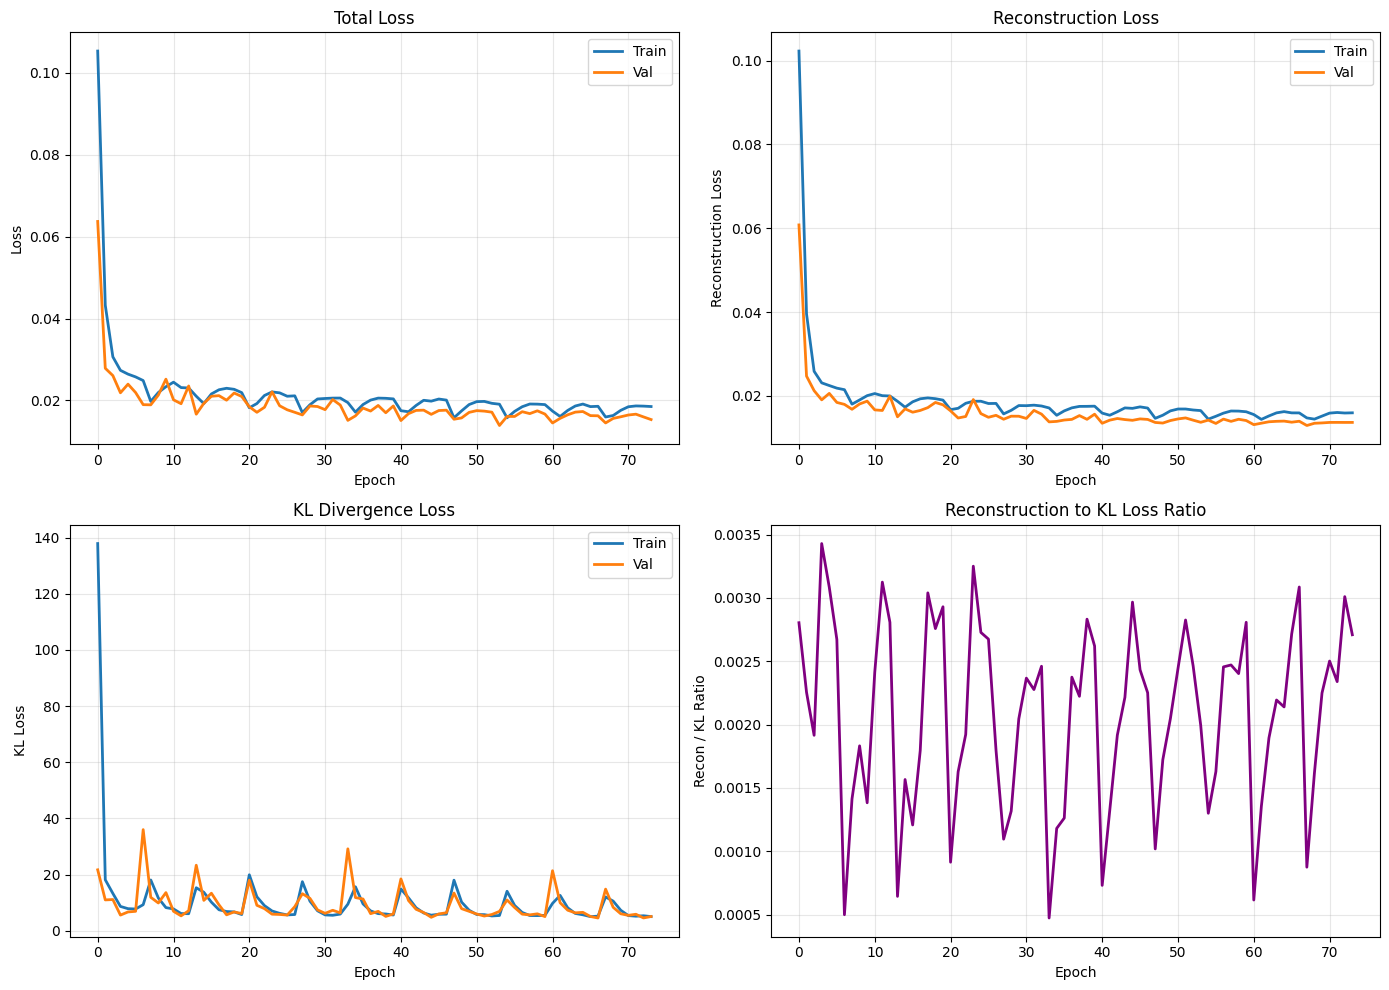

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(train_losses, label='Train', linewidth=2)
axes[0, 0].plot(val_losses, label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(train_recon_losses, label='Train', linewidth=2)
axes[0, 1].plot(val_recon_losses, label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KL loss
axes[1, 0].plot(train_kl_losses, label='Train', linewidth=2)
axes[1, 0].plot(val_kl_losses, label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Loss')
axes[1, 0].set_title('KL Divergence Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss ratio
recon_kl_ratio = [r / (k + 1e-8) for r, k in zip(val_recon_losses, val_kl_losses)]
axes[1, 1].plot(recon_kl_ratio, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recon / KL Ratio')
axes[1, 1].set_title('Reconstruction to KL Loss Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(checkpoint_dir, f"{model_name}_training_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

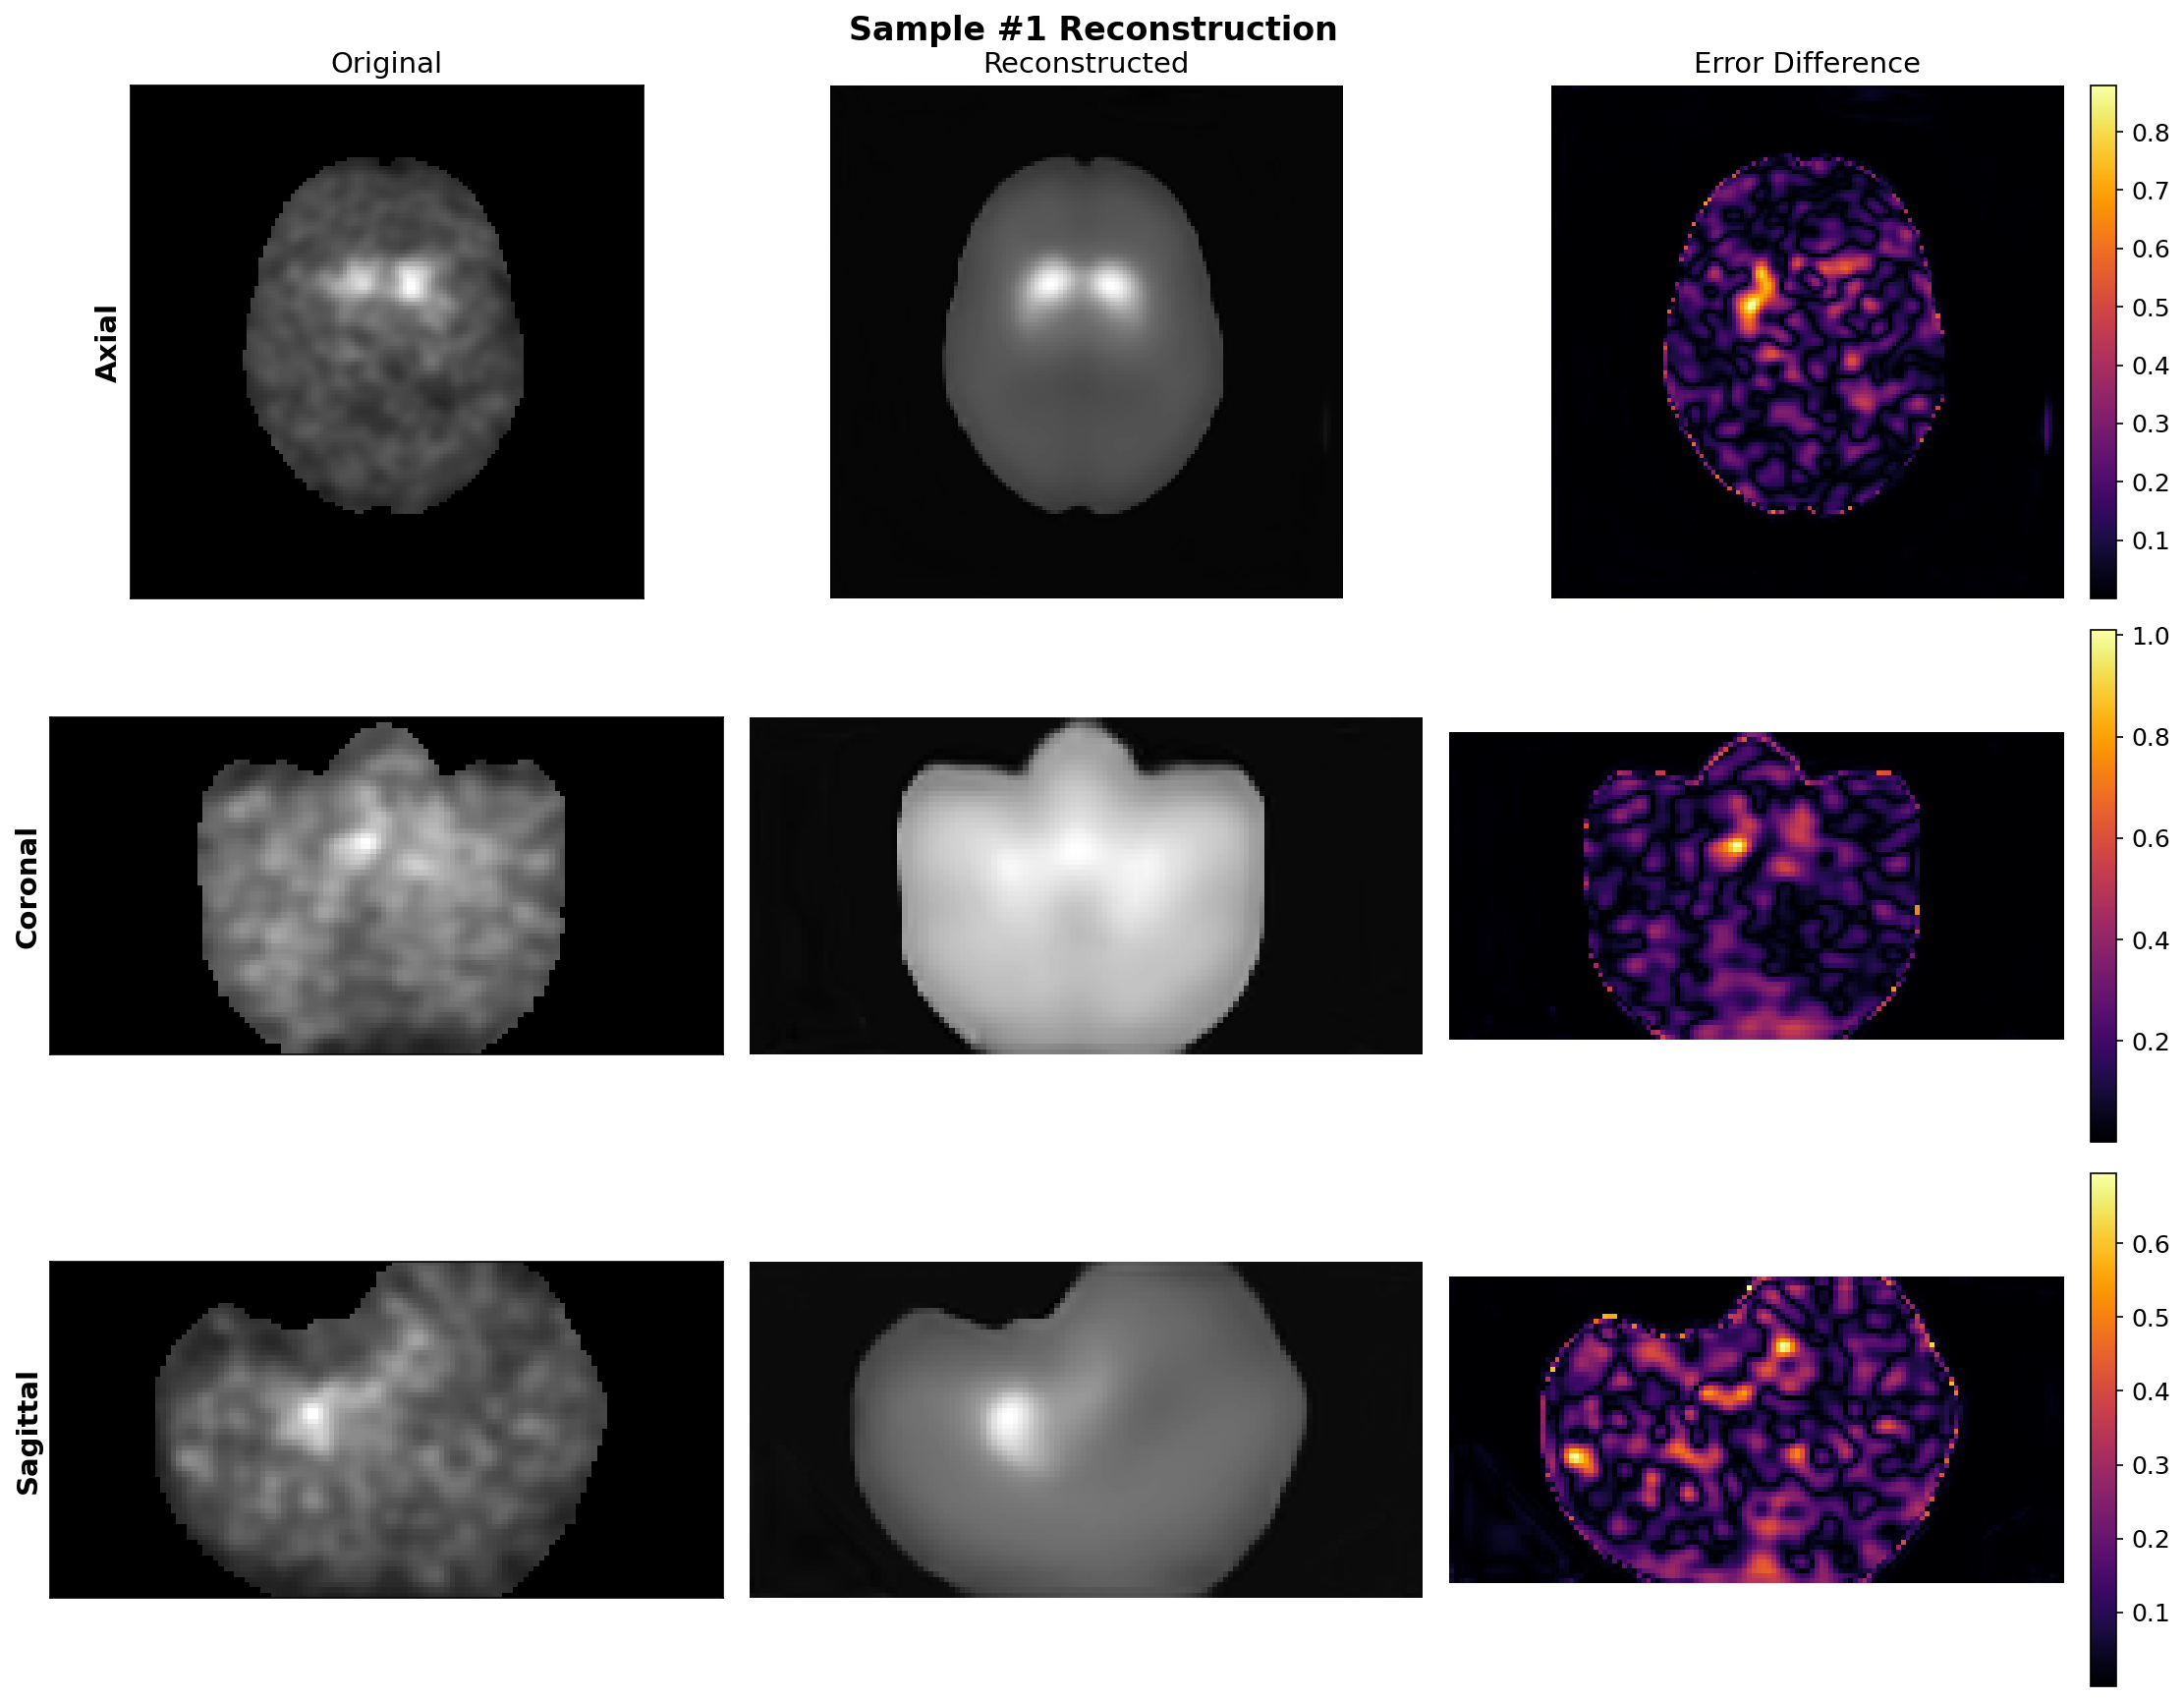

----------------------------------------------------------------------------------------------------


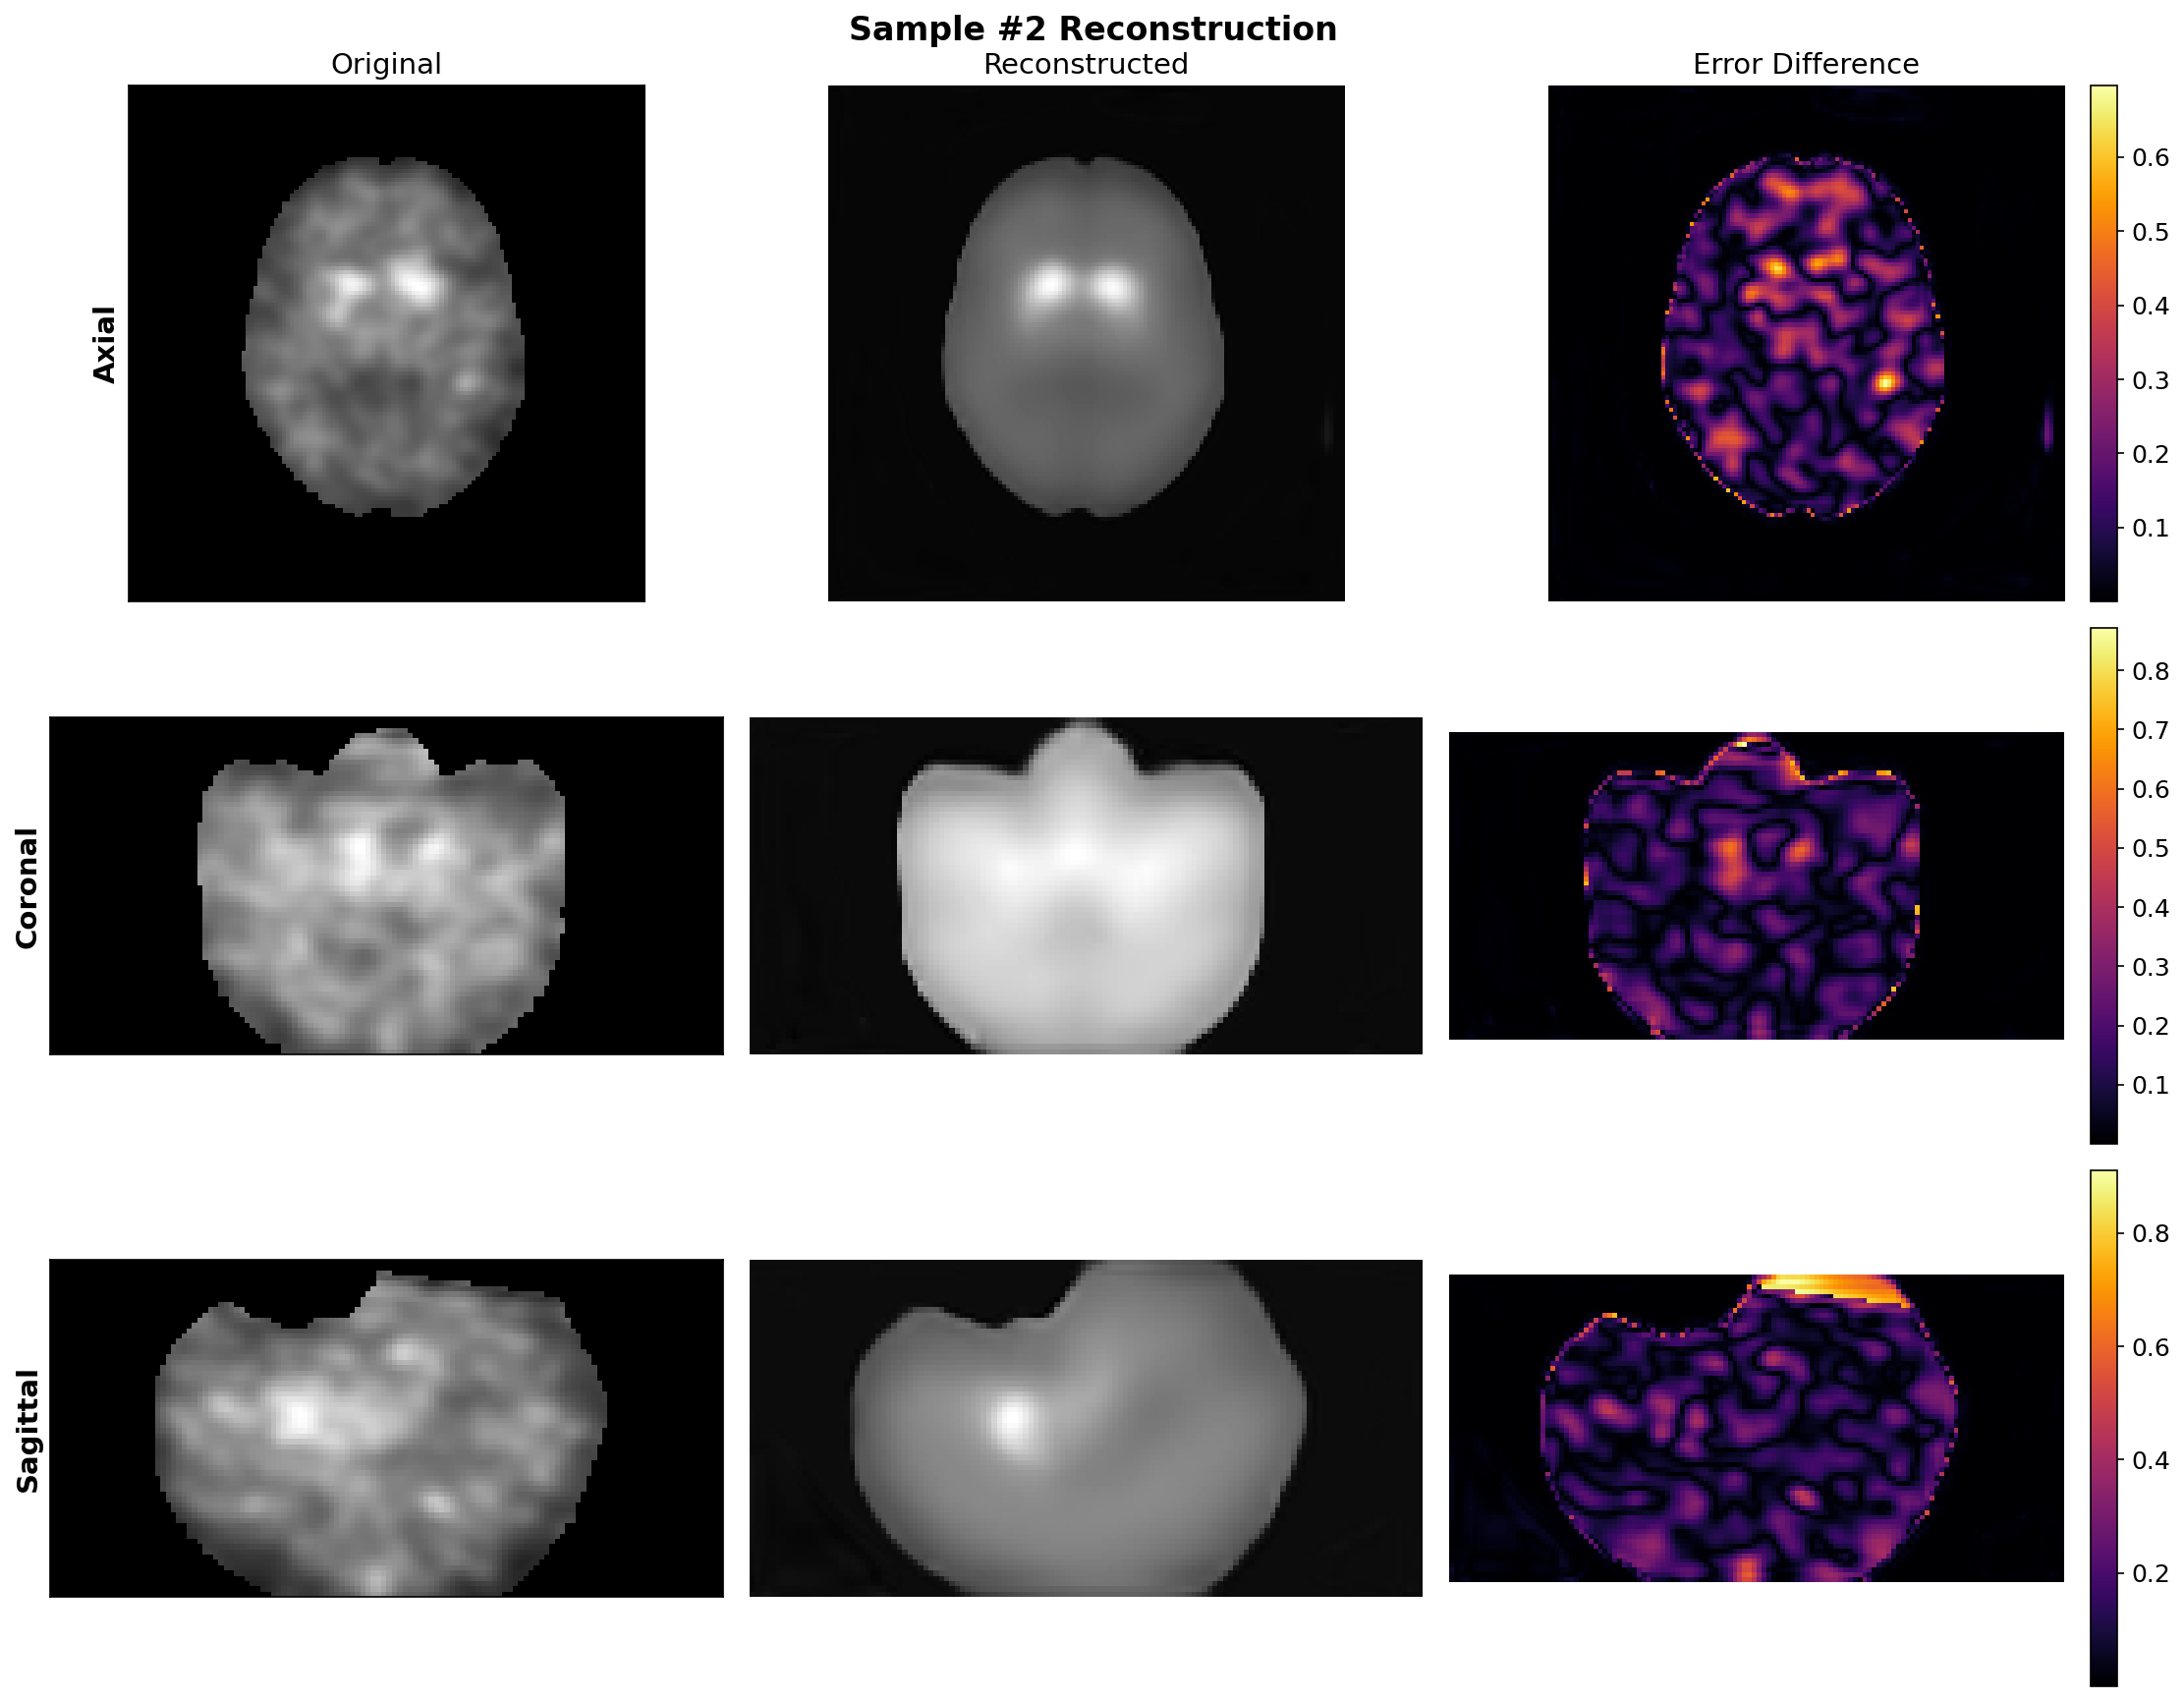

----------------------------------------------------------------------------------------------------


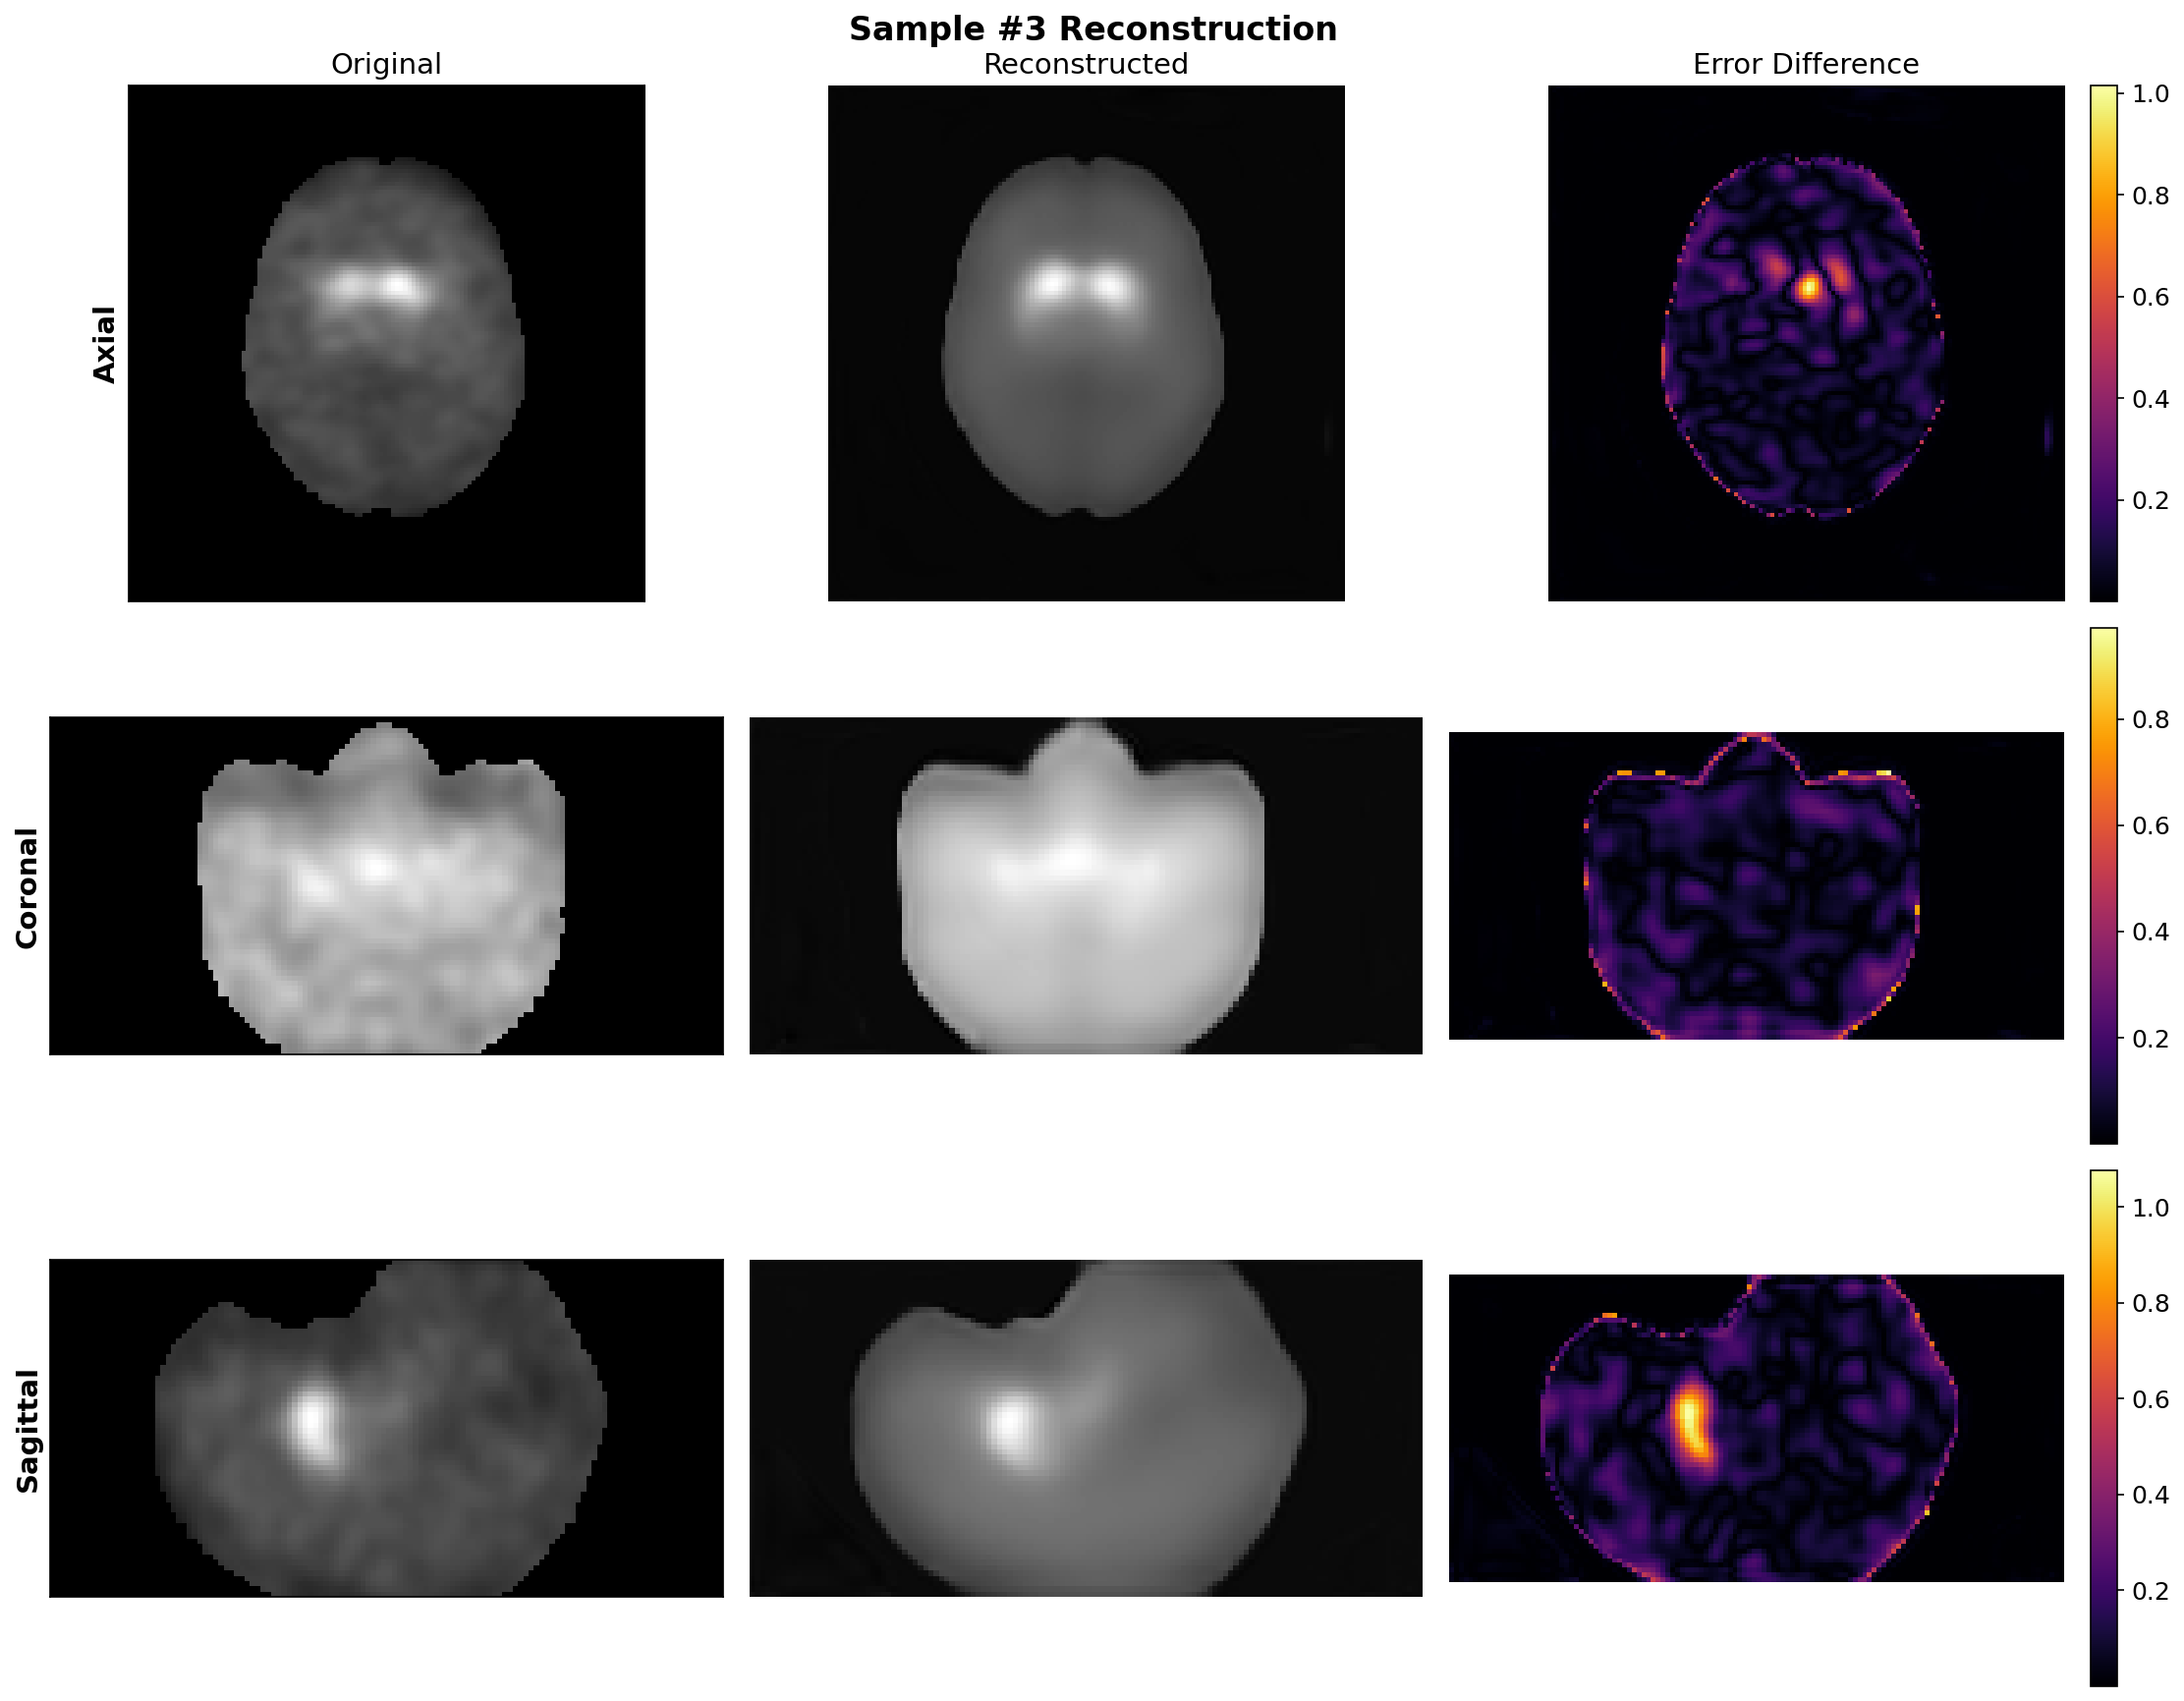

----------------------------------------------------------------------------------------------------


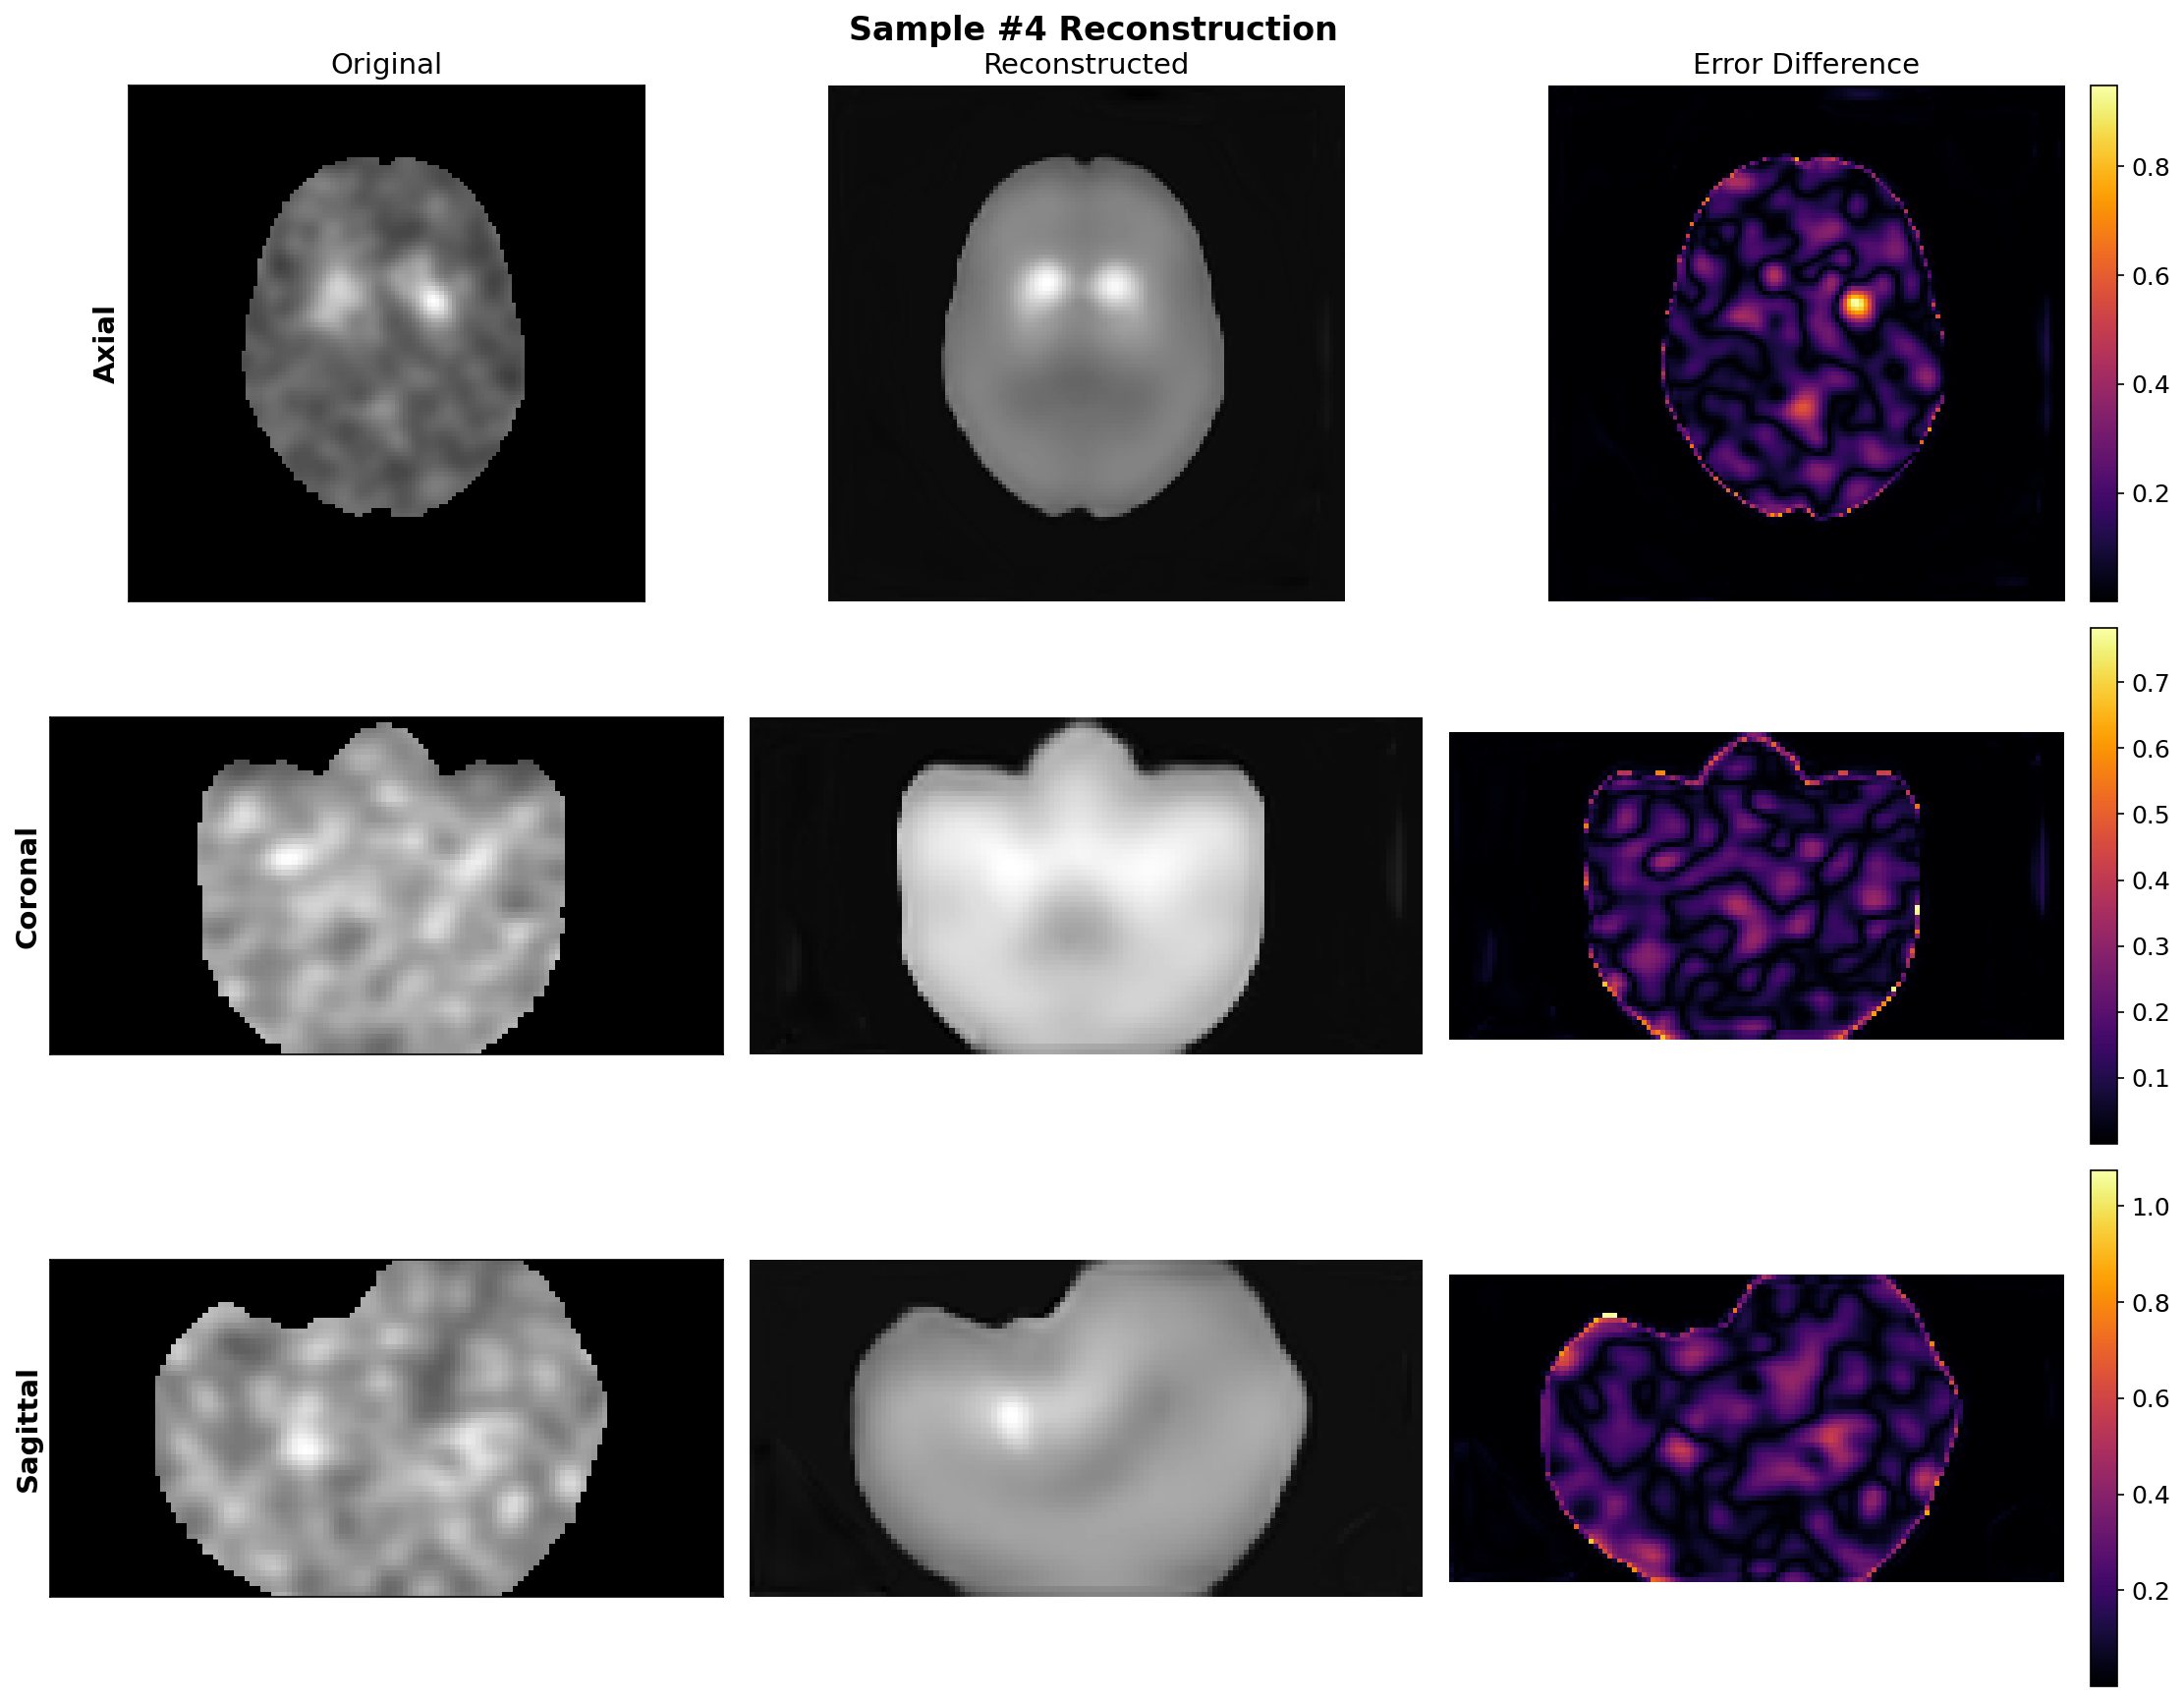

----------------------------------------------------------------------------------------------------


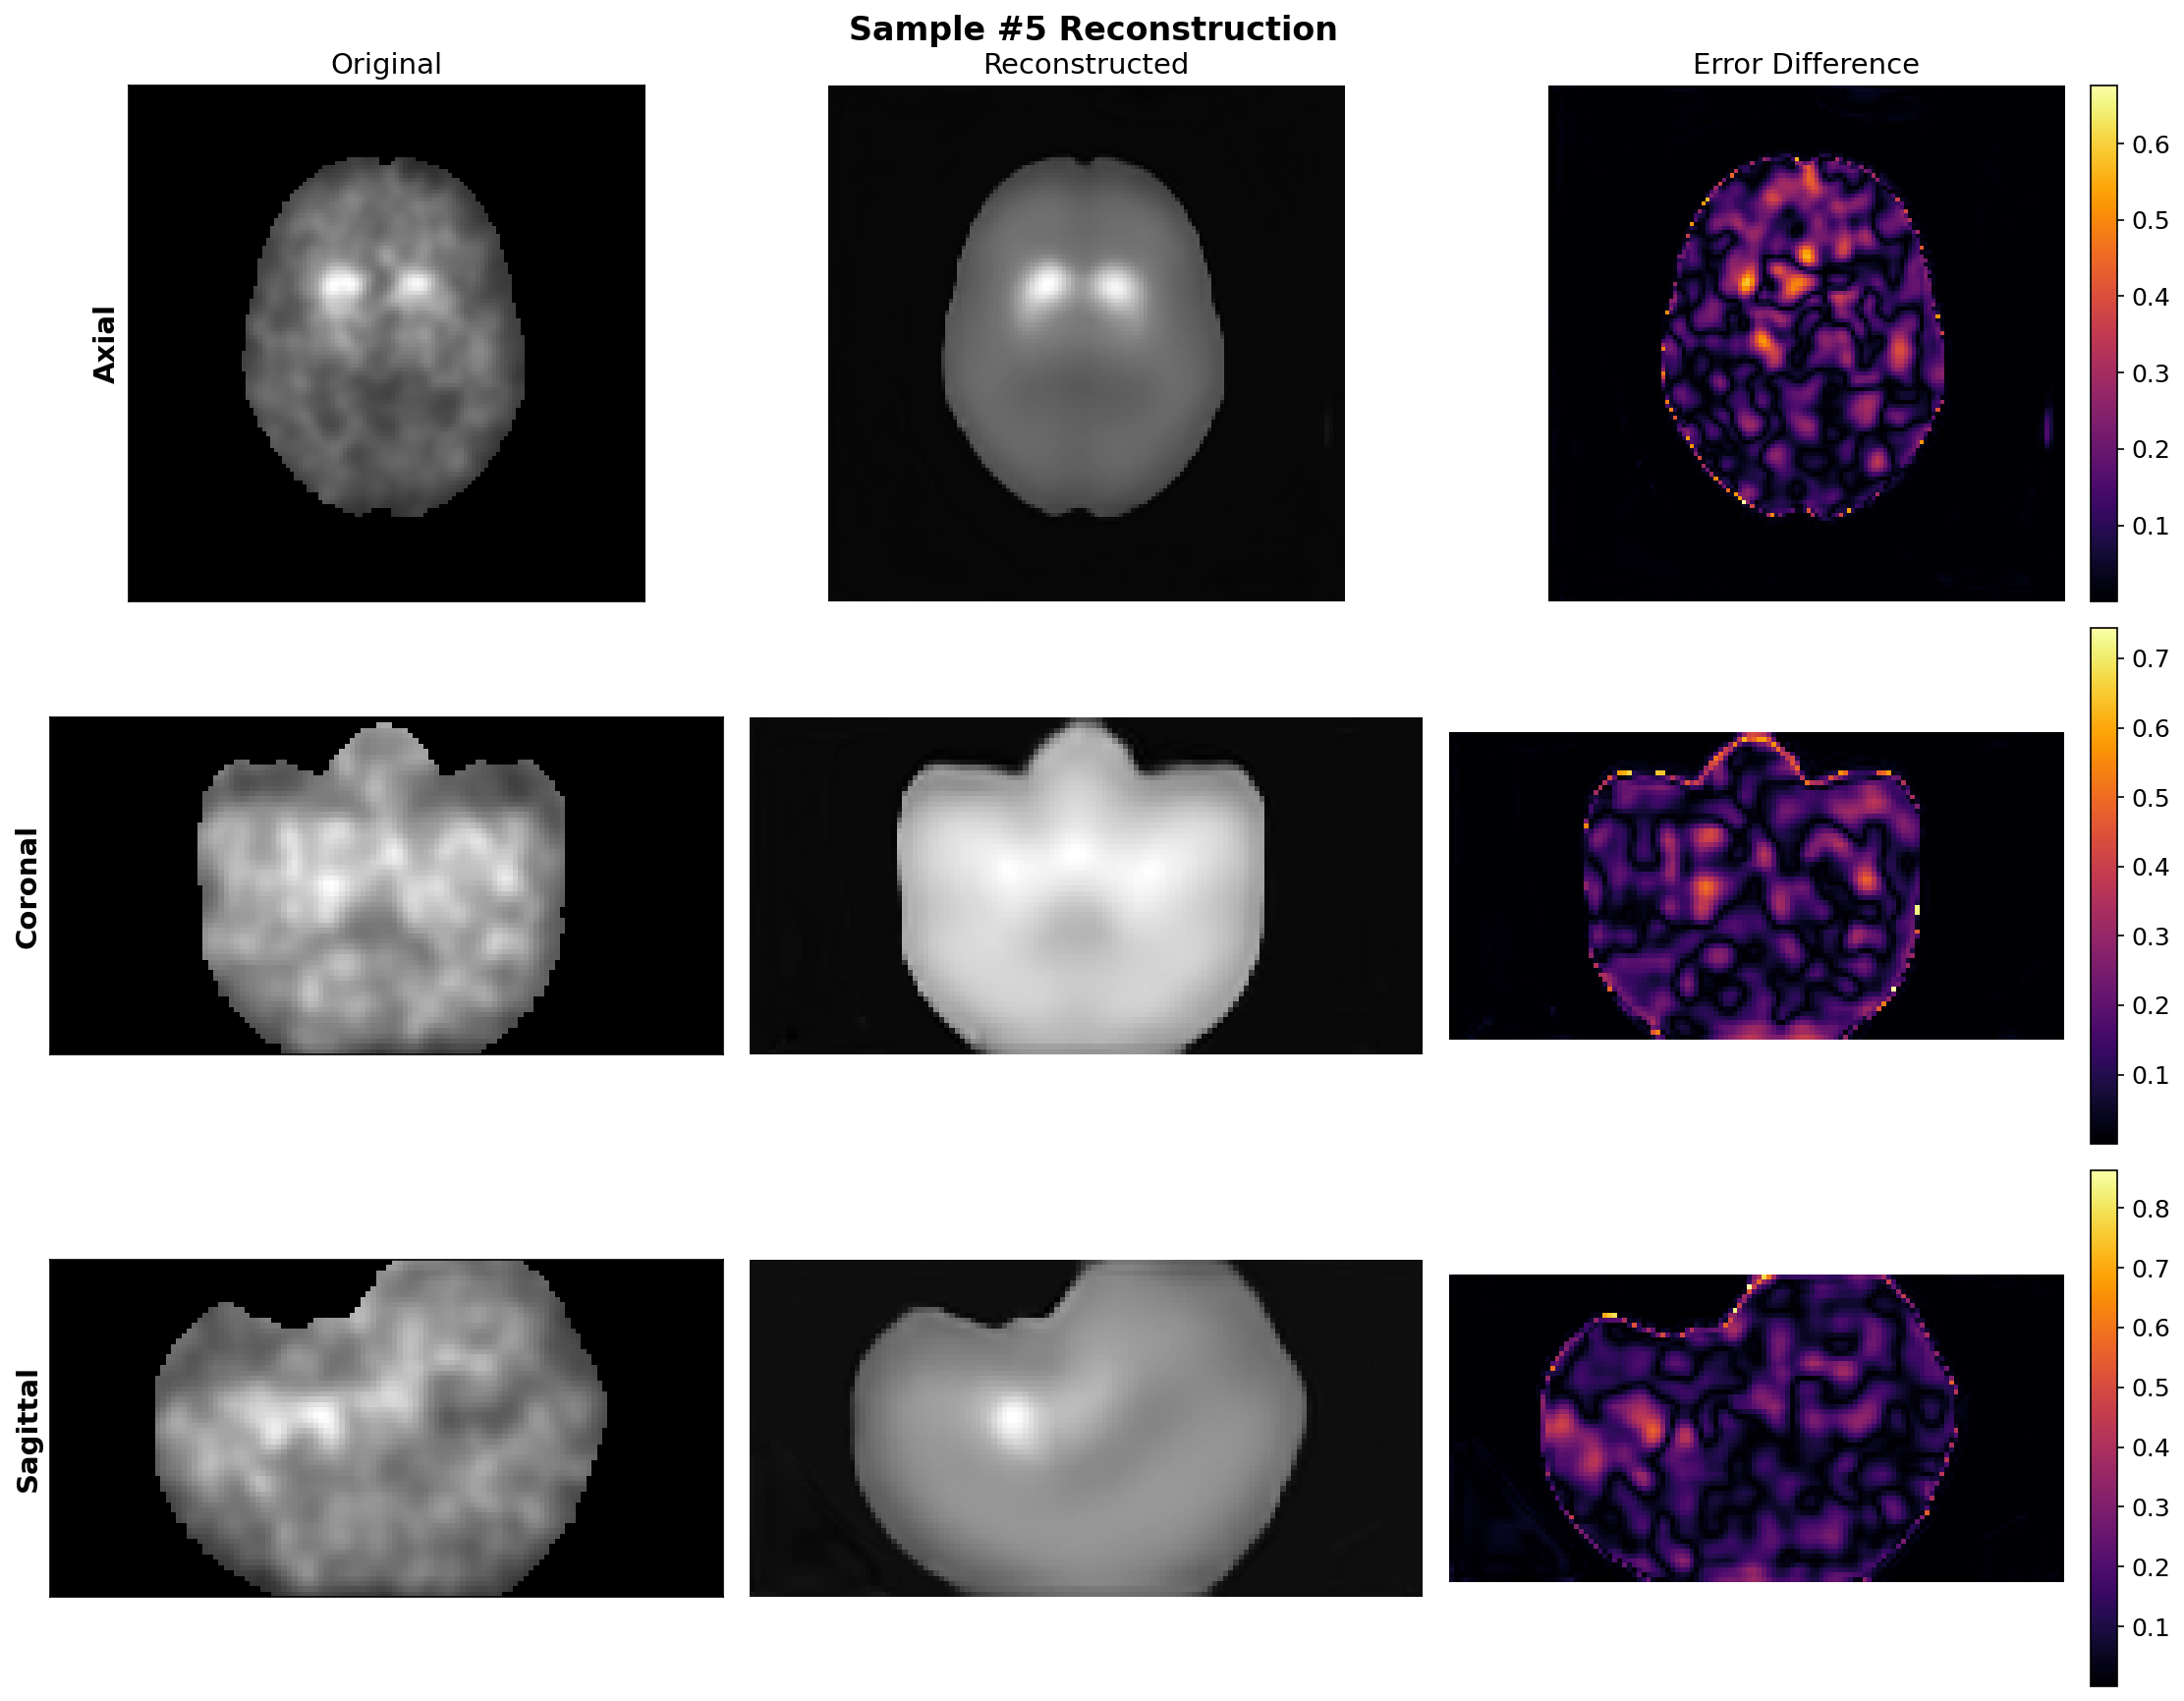

----------------------------------------------------------------------------------------------------


In [24]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- Step 1: Collect 5 Samples ---
num_samples_needed = 5
collected_images = []

# Iterate through loader until we have enough images
iter_loader = iter(val_loader)
while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        # Check if batch is dict or tuple and extract volume
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break # Stop if dataset is exhausted

# Stack and select exactly 5
if len(collected_images) < num_samples_needed:
    print(f"Warning: Only found {len(collected_images)} samples.")
    num_samples_needed = len(collected_images)

sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- Step 2: Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- Step 3: Visualization Loop ---
# Define slices (Depth, Height, Width)
slices_indices = {
    'Axial': (0, 32),    # dim 0
    'Coronal': (1, 64),  # dim 1
    'Sagittal': (2, 64)  # dim 2
}
views = ['Axial', 'Coronal', 'Sagittal']

def get_slice(data, dim, idx):
    if dim == 0: return data[idx, :, :]
    if dim == 1: return data[:, idx, :]
    if dim == 2: return data[:, :, idx]

# Loop through each sample and create a separate figure
for i in range(num_samples_needed):
    
    # Extract single sample (CPU numpy)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create a new Figure for this sample
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} Reconstruction", fontsize=16, weight='bold', y=0.96)
    
    for row_idx, view_name in enumerate(views):
        dim_idx, slice_idx = slices_indices[view_name]
        
        # Get slices
        orig_slice = get_slice(orig_np, dim_idx, slice_idx)
        recon_slice = get_slice(recon_np, dim_idx, slice_idx)
        error_slice = np.abs(orig_slice - recon_slice)
        
        # Column 1: Original
        axes[row_idx, 0].imshow(orig_slice, cmap='gray')
        axes[row_idx, 0].set_ylabel(view_name, fontsize=14, weight='bold') # Label the row
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # Column 2: Reconstructed
        axes[row_idx, 1].imshow(recon_slice, cmap='gray')
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # Column 3: Error
        im = axes[row_idx, 2].imshow(error_slice, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Add a colorbar specifically for the error plot
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Make room for main title
    plt.show()
    print("-" * 100) # Separator line

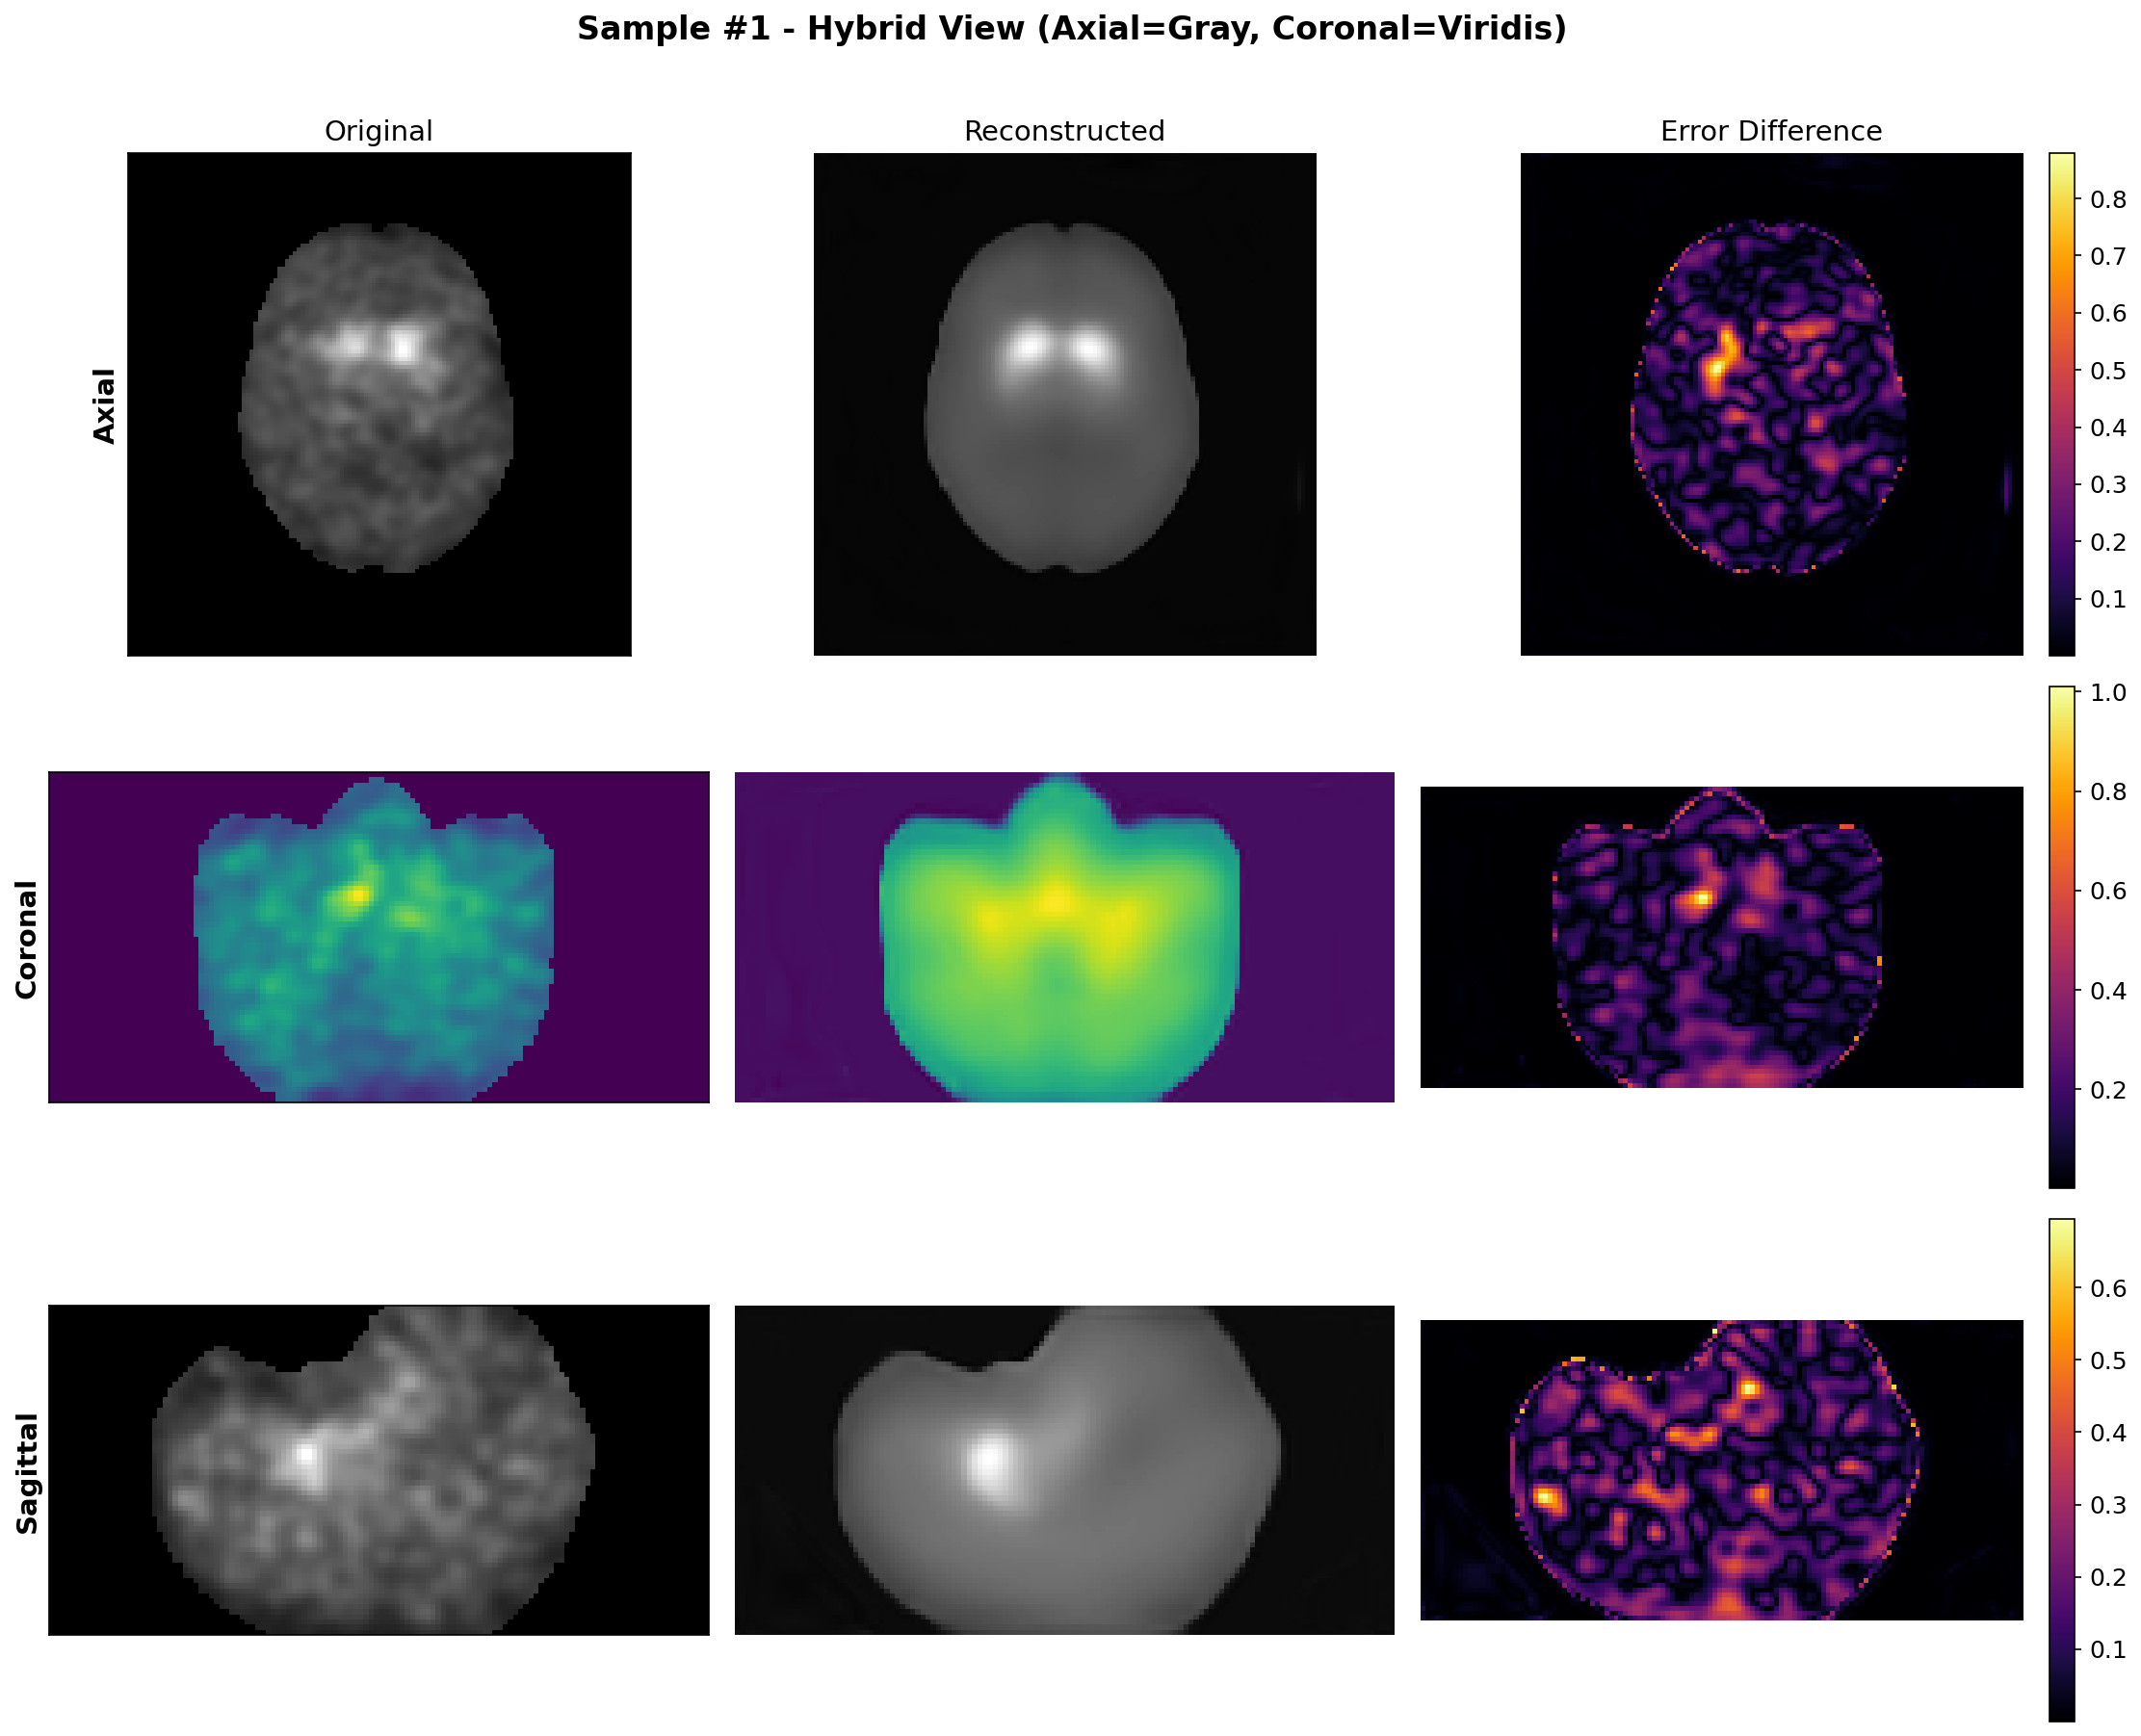

----------------------------------------------------------------------------------------------------


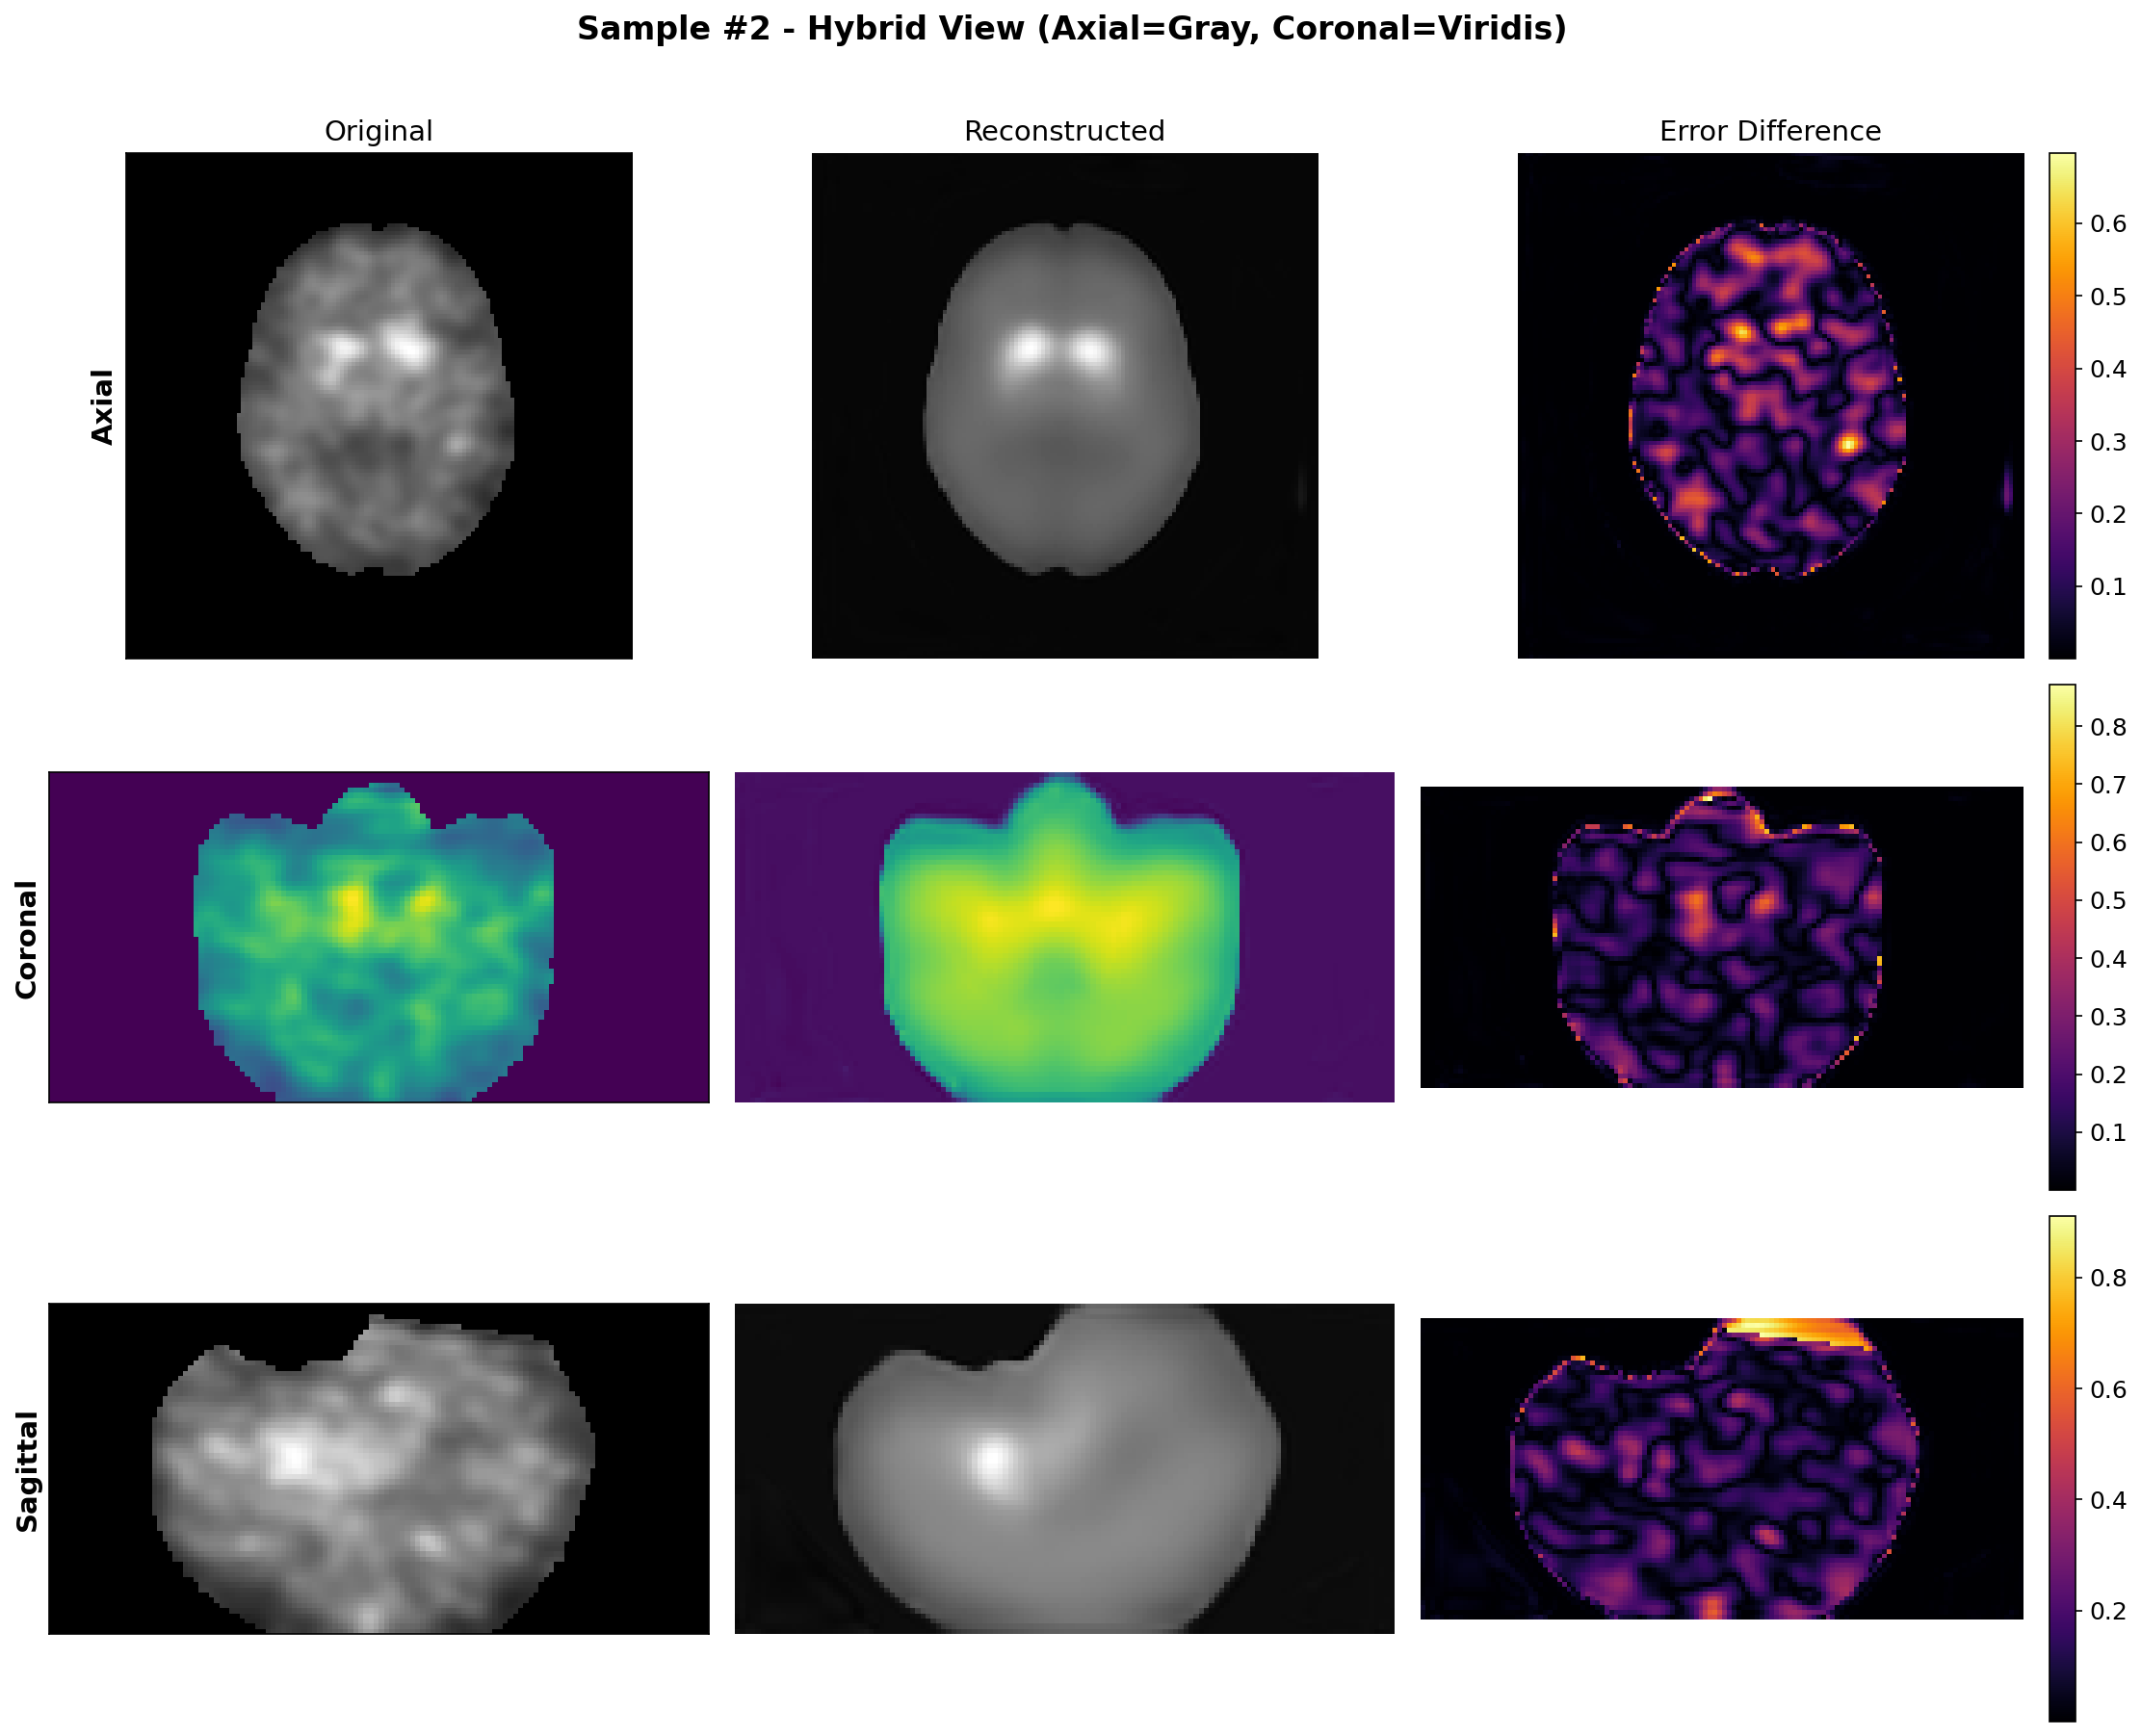

----------------------------------------------------------------------------------------------------


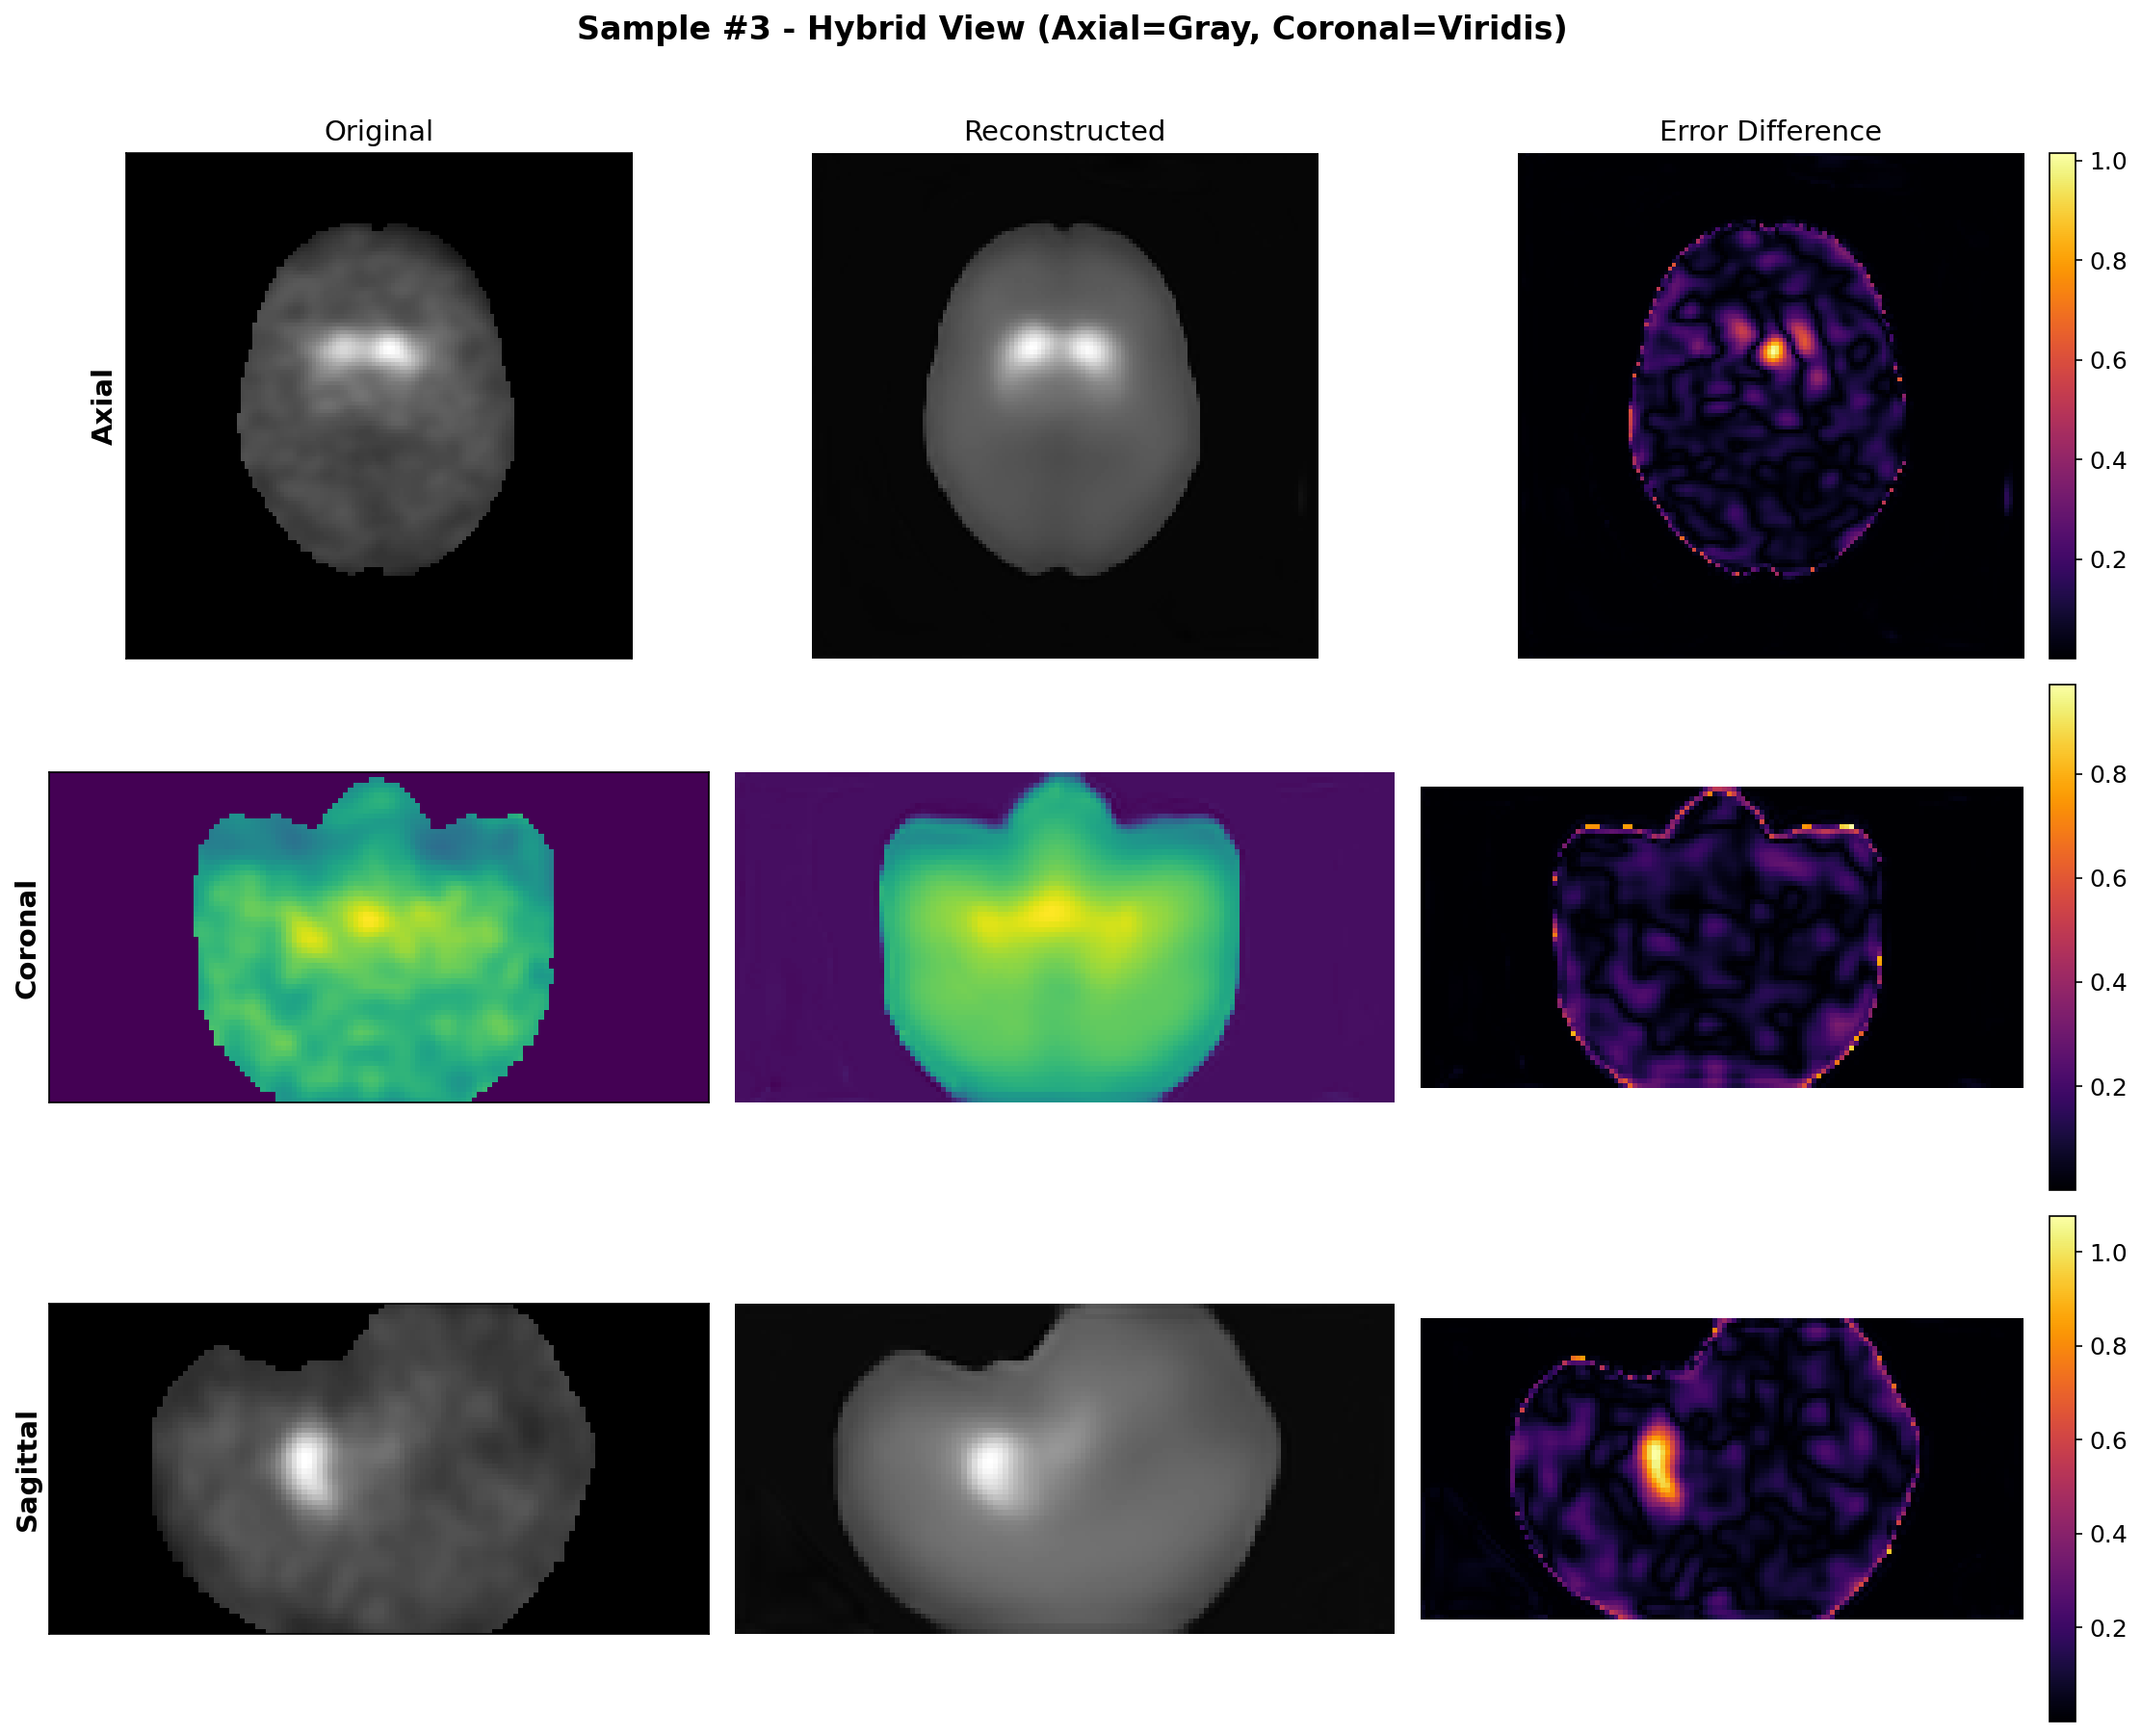

----------------------------------------------------------------------------------------------------


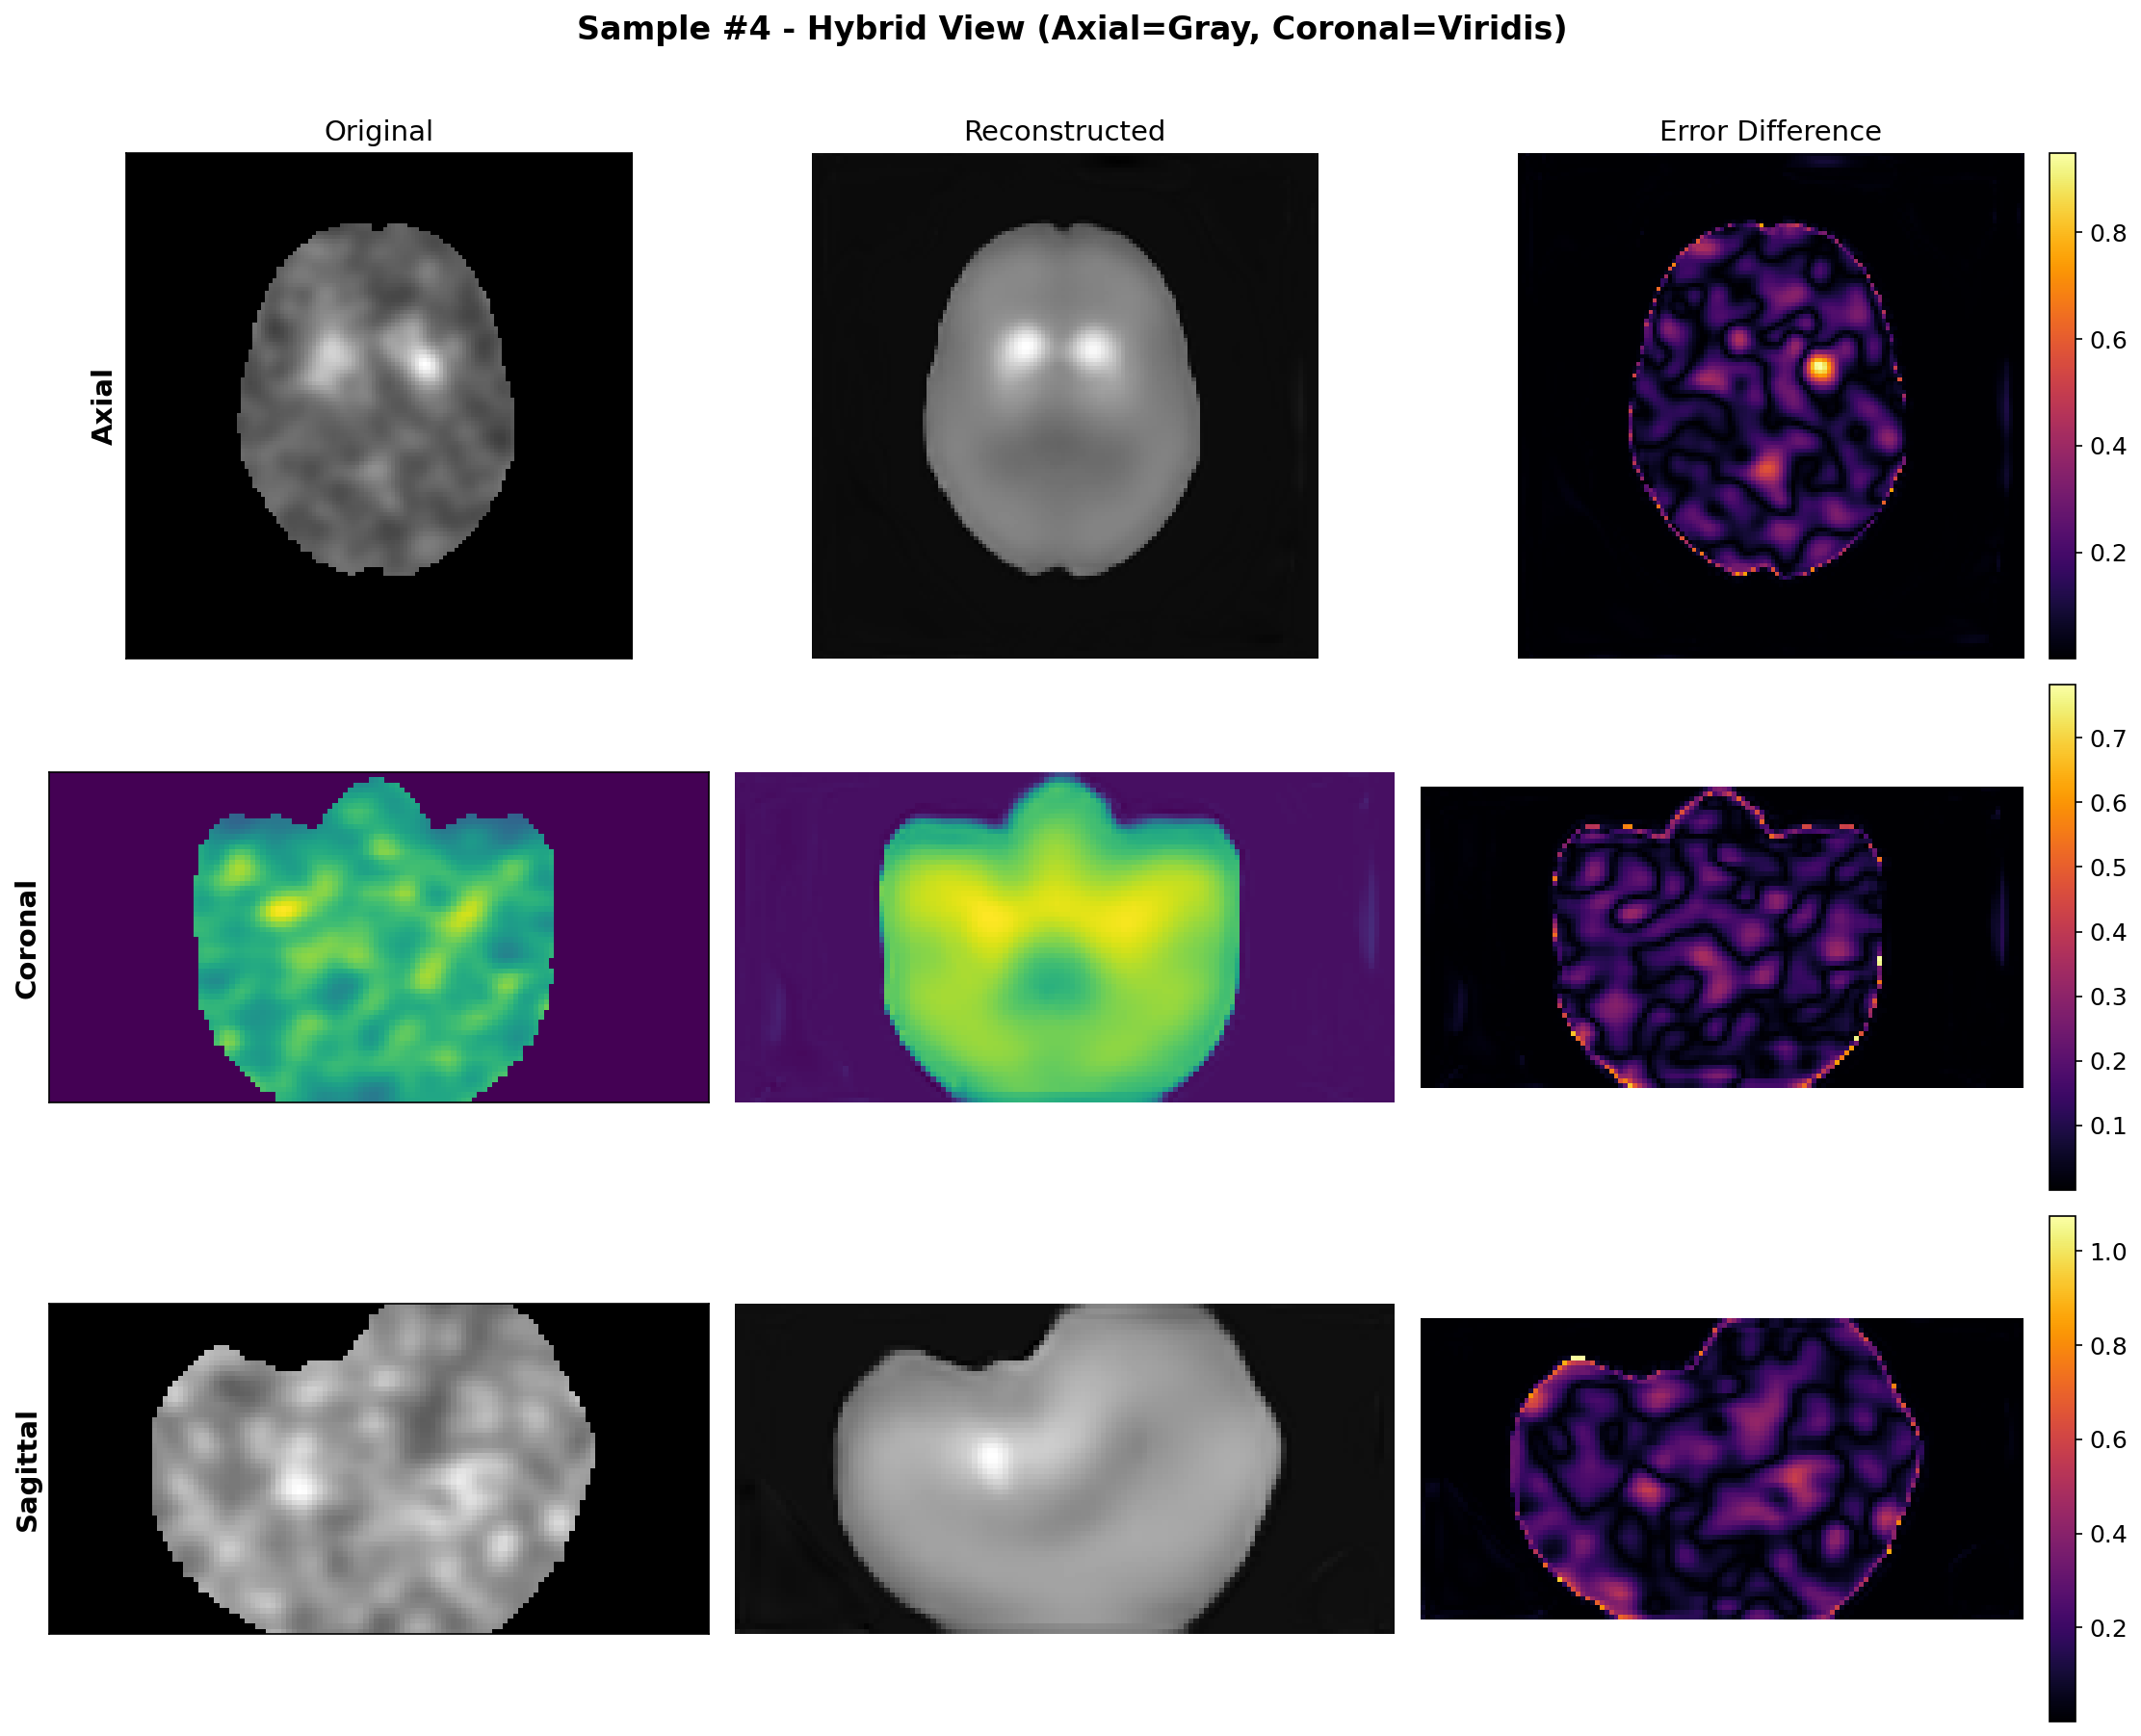

----------------------------------------------------------------------------------------------------


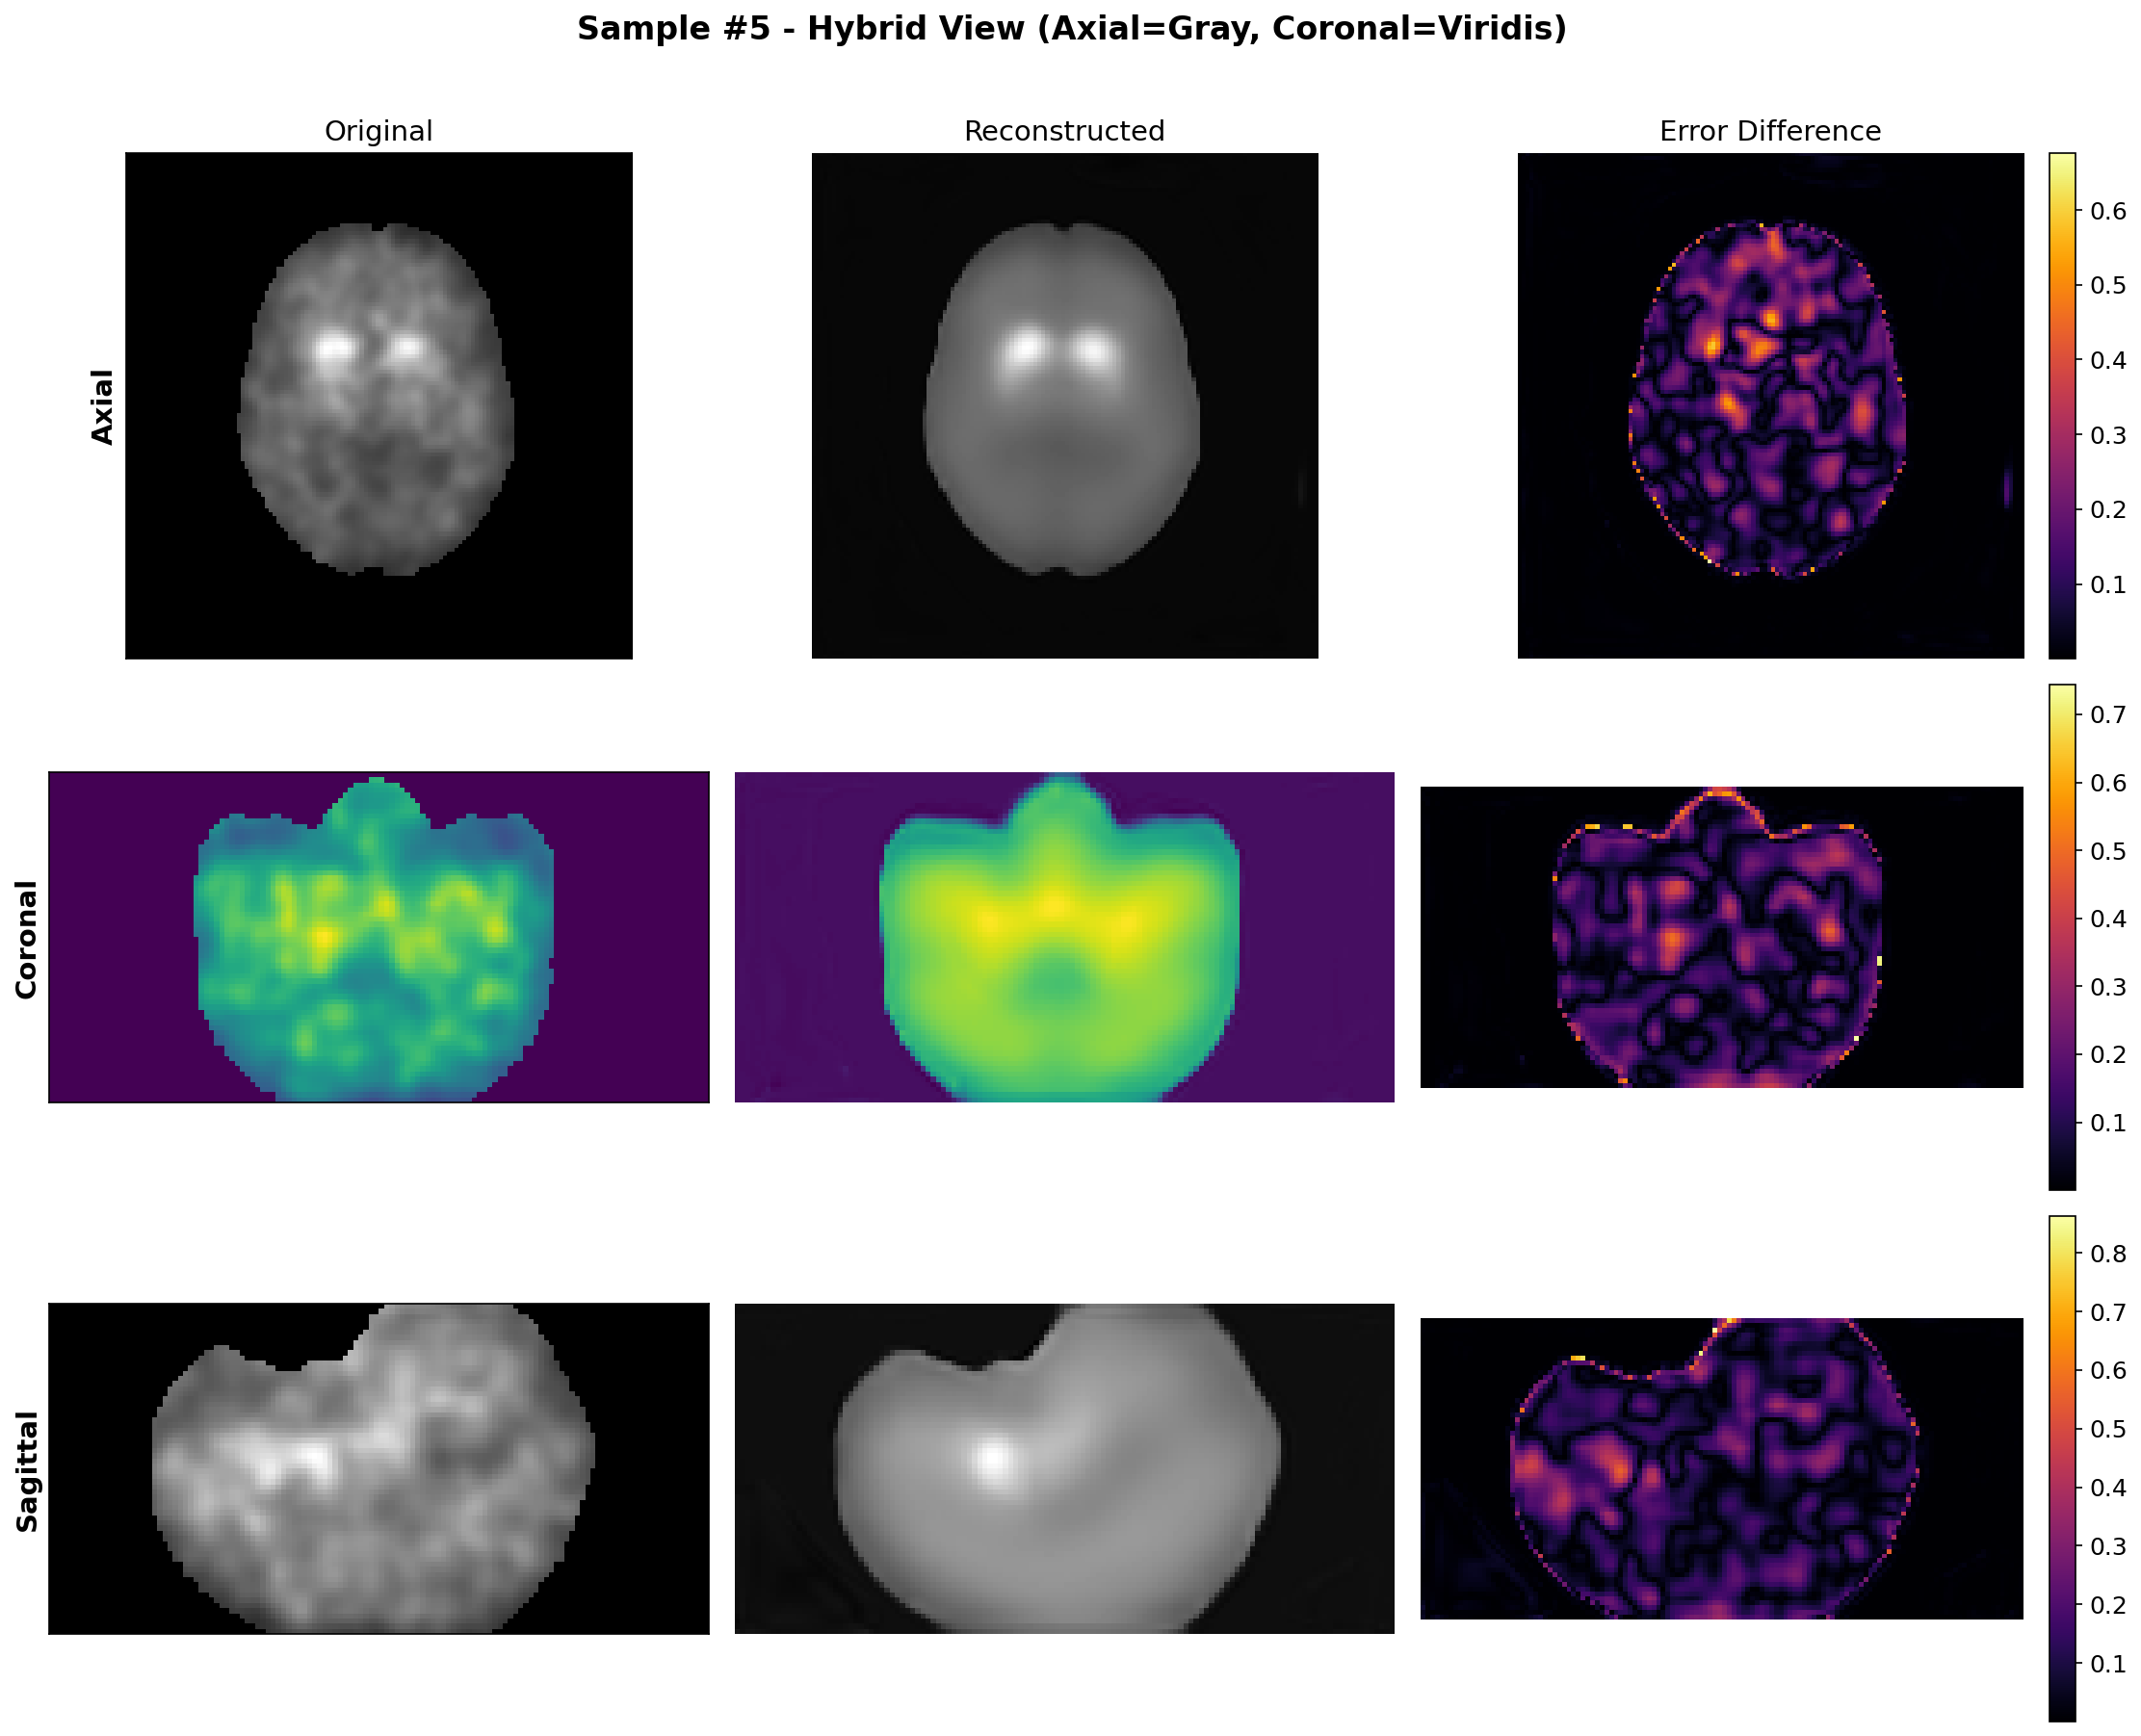

----------------------------------------------------------------------------------------------------


In [31]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- 1. Collect 5 Samples ---
num_samples_needed = 5
collected_images = []
iter_loader = iter(val_loader)

while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break 

# Convert to tensor
sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- 2. Calculate Center Slices ---
_, _, D, H, W = sample_data.shape
mid_d, mid_h, mid_w = D // 2, H // 2, W // 2

# Define View Settings: (Name, Dimension, Slice Index, Colormap)
view_settings = [
    ('Axial',    0, mid_d, 'gray'),    # Axial stays GRAY
    ('Coronal',  1, mid_h, 'viridis'), # Coronal gets COLOR (Viridis)
    ('Sagittal', 2, mid_w, 'gray')     # Sagittal stays GRAY
]

# --- 3. Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- 4. Visualization Loop ---
for i in range(num_samples_needed):
    
    # Extract data (CPU)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create Figure
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} - Hybrid View (Axial=Gray, Coronal=Viridis)", fontsize=16, weight='bold', y=1)
    
    for row_idx, (view_name, dim_idx, slice_idx, cmap_style) in enumerate(view_settings):
        
        # Helper: Extract Slices
        if dim_idx == 0: # Axial
            s_orig = orig_np[slice_idx, :, :]
            s_recon = recon_np[slice_idx, :, :]
        elif dim_idx == 1: # Coronal
            s_orig = orig_np[:, slice_idx, :]
            s_recon = recon_np[:, slice_idx, :]
        elif dim_idx == 2: # Sagittal
            s_orig = orig_np[:, :, slice_idx]
            s_recon = recon_np[:, :, slice_idx]

        # Calculate Error
        s_error = np.abs(s_orig - s_recon)
        
        # --- PLOT COLUMN 1: ORIGINAL ---
        # Note: No 'aspect=auto', so shape remains correct/normal
        axes[row_idx, 0].imshow(s_orig, cmap=cmap_style)
        axes[row_idx, 0].set_ylabel(f"{view_name}", fontsize=14, weight='bold')
        
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        
        # Hide ticks
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # --- PLOT COLUMN 2: RECONSTRUCTED ---
        axes[row_idx, 1].imshow(s_recon, cmap=cmap_style)
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # --- PLOT COLUMN 3: ERROR ---
        # Error is always heatmap (Inferno) for visibility
        im = axes[row_idx, 2].imshow(s_error, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Colorbar
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    print("-" * 100)

## Load Best Model and Test

In [18]:
# Load best model
best_model = build_vae_model(latent_dim=latent_dim)
best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
best_model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best model from: {best_model_path}")

# Test on a few samples
best_model.eval()
with torch.no_grad():
    # 1. Get the dictionary batch
    batch = next(iter(val_loader))
    
    # 2. Extract the actual image tensor using the 'volume' key
    # (The error logs show 'volume' is one of the keys)
    test_data = batch['volume']
    
    # 3. Now you can move it to device
    test_data = test_data.to(device)
    
    # Forward pass
    recon, mu, log_var = best_model(test_data)
    
    # Compute loss
    loss, recon_loss, kl_loss, beta = criterion(recon, test_data, mu, log_var)
    
    print(f"\nTest Batch Results:")
    print(f"Total Loss: {loss.item():.6f}")
    print(f"Reconstruction Loss: {recon_loss.item():.6f}")
    print(f"KL Loss: {kl_loss.item():.6f}")
    print(f"Beta: {beta:.6f}")
    print(f"Latent Mean: {mu.mean().item():.6f}")
    print(f"Latent Std: {mu.std().item():.6f}")

Loaded best model from: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Test Batch Results:
Total Loss: 0.015505
Reconstruction Loss: 0.015443
KL Loss: 5.475583
Beta: 0.000011
Latent Mean: -0.007957
Latent Std: 0.234774
